# Exploratory Data Analysis (EDA) - Полное руководство

## Что такое EDA?

**Exploratory Data Analysis (EDA)** — это процесс исследования и анализа данных для:
- Понимания структуры данных
- Выявления закономерностей и аномалий
- Формулирования гипотез
- Подготовки данных к дальнейшему анализу или моделированию

## Структура EDA

EDA обычно состоит из следующих этапов:

1. **Загрузка и первичный осмотр данных**
2. **Изучение структуры данных**
3. **Проверка качества данных**
4. **Описательная статистика**
5. **Визуализация данных**
6. **Анализ взаимосвязей**
7. **Формулирование выводов и гипотез**

---

## О датасете

В этом ноутбуке мы будем работать с **Olist E-commerce Dataset** — датасетом бразильского интернет-магазина Olist.

**Датасет включает:**
- Заказы (orders)
- Клиенты (customers)
- Товары (products)
- Элементы заказов (order items)
- Платежи (payments)
- Отзывы (reviews)
- Продавцы (sellers)
- Геолокация (geolocation)
- Переводы категорий (category translations)


In [46]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os

# Настройка стиля
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

# Увеличение размера графиков
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("Библиотеки успешно импортированы!")
print(f"Pandas версия: {pd.__version__}")
print(f"NumPy версия: {np.__version__}")
print(f"Matplotlib версия: {plt.matplotlib.__version__}")
print(f"Seaborn версия: {sns.__version__}")


Библиотеки успешно импортированы!
Pandas версия: 2.0.0
NumPy версия: 1.23.5
Matplotlib версия: 3.7.1
Seaborn версия: 0.12.2


# Этап 1: Загрузка данных

## Шаги:
1. Определяем путь к данным
2. Загружаем все CSV файлы
3. Проверяем успешность загрузки
4. Создаем словарь для удобного доступа к датасетам


In [47]:
# Определяем путь к данным
data_path = "data/"

# Список всех файлов данных
data_files = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

# Загружаем все датасеты
data = {}
for name, filename in data_files.items():
    filepath = os.path.join(data_path, filename)
    try:
        data[name] = pd.read_csv(filepath)
        print(f"✓ {name}: {len(data[name])} строк, {len(data[name].columns)} столбцов")
    except Exception as e:
        print(f"✗ Ошибка при загрузке {name}: {e}")

print(f"\nВсего загружено датасетов: {len(data)}")


✓ orders: 99441 строк, 8 столбцов
✓ customers: 99441 строк, 5 столбцов
✓ products: 32951 строк, 9 столбцов
✓ order_items: 112650 строк, 7 столбцов
✓ payments: 103886 строк, 5 столбцов
✓ reviews: 99224 строк, 7 столбцов
✓ sellers: 3095 строк, 4 столбцов
✓ geolocation: 1000163 строк, 5 столбцов
✓ category_translation: 71 строк, 2 столбцов

Всего загружено датасетов: 9


# Этап 2: Первичный осмотр данных

## Цели этапа:
- Понять структуру каждого датасета
- Увидеть примеры данных
- Определить типы данных
- Оценить размеры датасетов


In [51]:
# Функция для быстрого обзора датасета
def quick_overview(df, name):
    """Выводит основную информацию о датасете"""
    print(f"\n{'=' * 60}")
    print(f"ДАТАСЕТ: {name.upper()}")
    print(f"{'=' * 60}")
    print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    print(f"\nСтолбцы и типы данных:")
    print(df.dtypes)
    print(f"\nПервые 3 строки:")
    display(df.head(3))
    print(f"\nИнформация о памяти:")
    print(f"Использовано памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df.info()


# Просматриваем все датасеты
for name, df in data.items():
    quick_overview(df, name)



ДАТАСЕТ: ORDERS
Размер: 99,441 строк × 8 столбцов

Столбцы и типы данных:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Первые 3 строки:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



Информация о памяти:
Использовано памяти: 58.97 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

ДАТАСЕТ: CUSTOMERS
Размер: 99,441 строк × 5 столбцов

Столбцы и типы данных:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city              

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



Информация о памяти:
Использовано памяти: 29.62 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

ДАТАСЕТ: PRODUCTS
Размер: 32,951 строк × 9 столбцов

Столбцы и типы данных:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              f

...


Информация о памяти:
Использовано памяти: 0.66 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

ДАТАСЕТ: GEOLOCATION
Размер: 1,000,163 строк × 5 столбцов

Столбцы и типы данных:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Первые 3 строки:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



Информация о памяти:
Использовано памяти: 145.20 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

ДАТАСЕТ: CATEGORY_TRANSLATION
Размер: 71 строк × 2 столбцов

Столбцы и типы данных:
product_category_name            object
product_category_name_english    object
dtype: object

Первые 3 строки:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



Информация о памяти:
Использовано памяти: 0.01 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


## Понимание связей между таблицами

**Ключевые связи:**
- `orders` ↔ `customers` (через `customer_id`)
- `orders` ↔ `order_items` (через `order_id`)
- `order_items` ↔ `products` (через `product_id`)
- `order_items` ↔ `sellers` (через `seller_id`)
- `orders` ↔ `payments` (через `order_id`)
- `orders` ↔ `reviews` (через `order_id`)
- `products` ↔ `category_translation` (через `product_category_name`)

**Схема данных:**
```
customers → orders → order_items → products
                      ↓
                   sellers
orders → payments
orders → reviews
products → category_translation
```


# Этап 3: Проверка качества данных

## Что проверяем:
1. **Пропущенные значения** (missing values)
2. **Дубликаты** (duplicates)
3. **Аномальные значения** (outliers)
4. **Некорректные типы данных**
5. **Неконсистентность данных**



ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ в ORDERS


,Столбец,Пропущено,Процент
6,order_delivered_customer_date,2965,2.981668
5,order_delivered_carrier_date,1783,1.793023
4,order_approved_at,160,0.160899


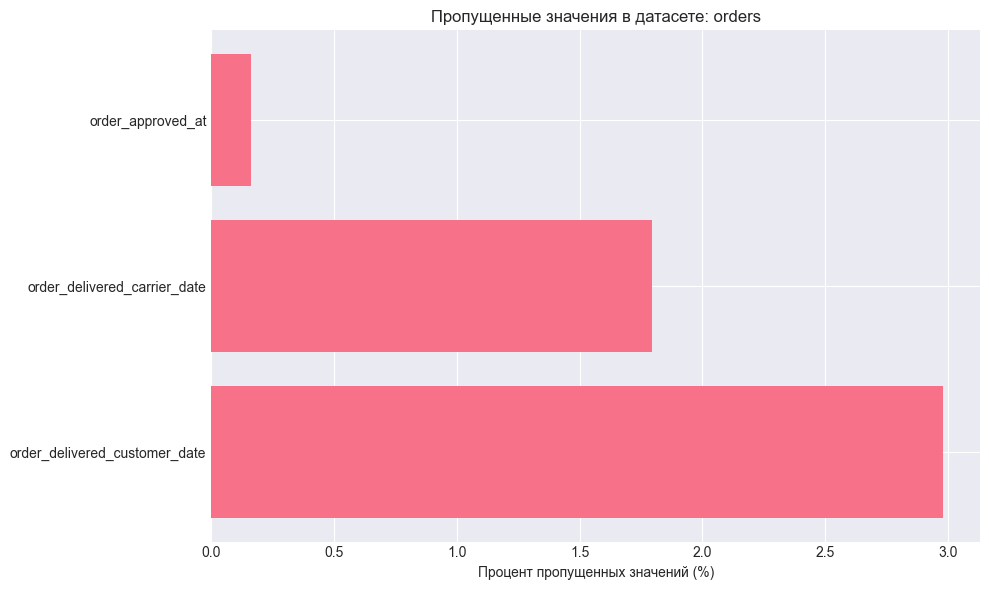


✓ В датасете customers нет пропущенных значений!

ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ в PRODUCTS


,Столбец,Пропущено,Процент
1,product_category_name,610,1.851234
2,product_name_lenght,610,1.851234
3,product_description_lenght,610,1.851234
4,product_photos_qty,610,1.851234
5,product_weight_g,2,0.006070
6,product_length_cm,2,0.006070
7,product_height_cm,2,0.006070
8,product_width_cm,2,0.006070


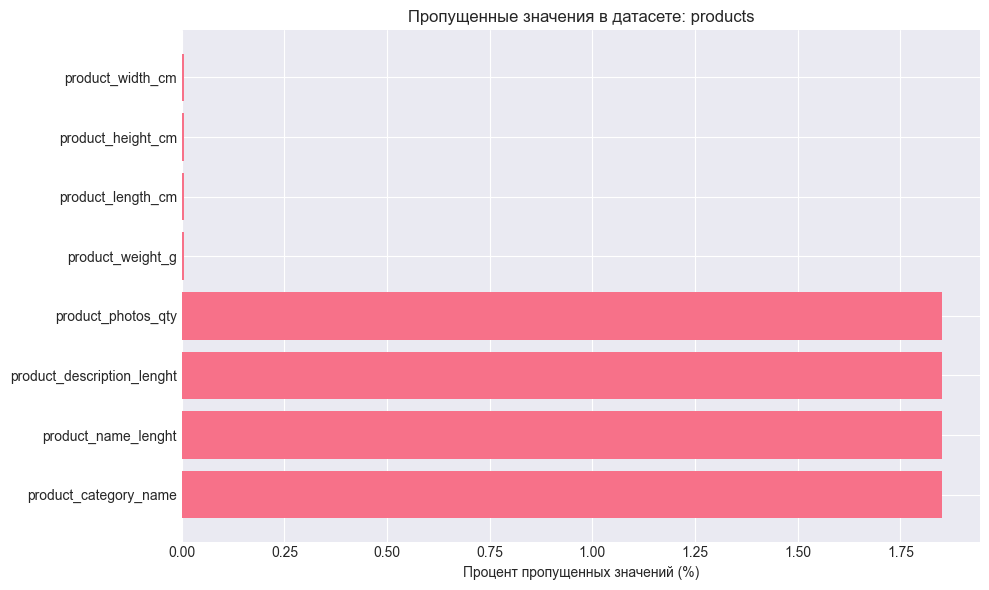


✓ В датасете order_items нет пропущенных значений!

✓ В датасете payments нет пропущенных значений!

ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ в REVIEWS


,Столбец,Пропущено,Процент
3,review_comment_title,87656,88.341530
4,review_comment_message,58247,58.702532


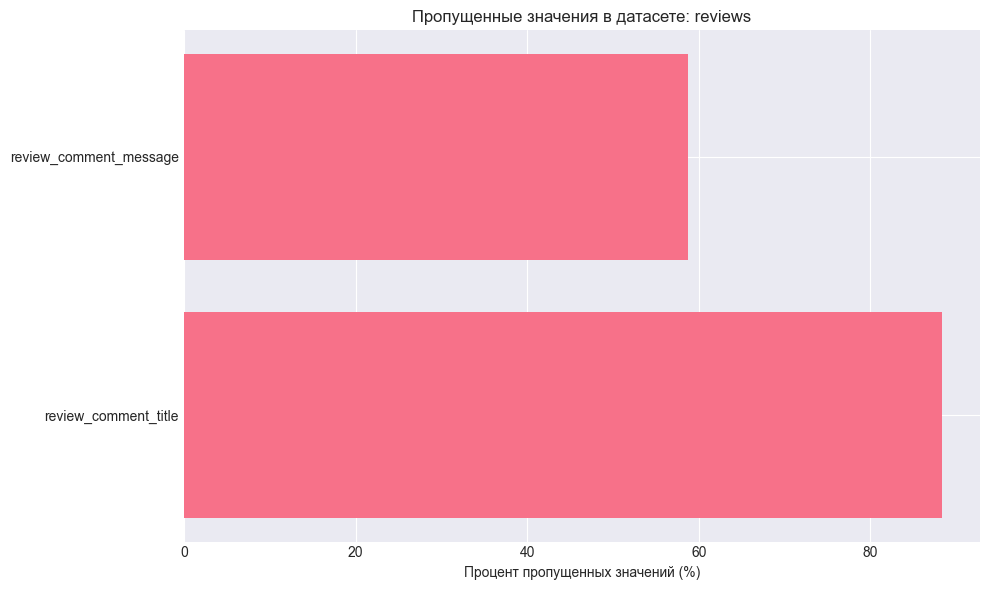


✓ В датасете sellers нет пропущенных значений!

✓ В датасете geolocation нет пропущенных значений!

✓ В датасете category_translation нет пропущенных значений!


In [4]:
# Функция для проверки пропущенных значений
def check_missing_values(df, name):
    """Проверяет и визуализирует пропущенные значения"""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame(
        {
            "Столбец": missing.index,
            "Пропущено": missing.values,
            "Процент": missing_pct.values,
        }
    )
    missing_df = missing_df[missing_df["Пропущено"] > 0].sort_values(
        "Пропущено", ascending=False
    )

    if len(missing_df) > 0:
        print(f"\n{'=' * 60}")
        print(f"ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ в {name.upper()}")
        print(f"{'=' * 60}")
        display(missing_df)

        # Визуализация
        if len(missing_df) > 0:
            plt.figure(figsize=(10, 6))
            plt.barh(missing_df["Столбец"], missing_df["Процент"])
            plt.xlabel("Процент пропущенных значений (%)")
            plt.title(f"Пропущенные значения в датасете: {name}")
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n✓ В датасете {name} нет пропущенных значений!")

    return missing_df


# Проверяем пропущенные значения во всех датасетах
missing_summary = {}
for name, df in data.items():
    missing_summary[name] = check_missing_values(df, name)


In [52]:
# Проверка дубликатов
def check_duplicates(df, name, key_column=None):
    """Проверяет дубликаты в датасете"""
    print(f"\n{'=' * 60}")
    print(f"ПРОВЕРКА ДУБЛИКАТОВ в {name.upper()}")
    print(f"{'=' * 60}")

    # Полные дубликаты строк
    full_duplicates = df.duplicated().sum()
    print(f"Полных дубликатов строк: {full_duplicates}")

    # Дубликаты по ключевому столбцу (если указан)
    if key_column and key_column in df.columns:
        key_duplicates = df[key_column].duplicated().sum()
        print(f"Дубликатов по ключу '{key_column}': {key_duplicates}")
        if key_duplicates > 0:
            print(f"Примеры дубликатов:")
            display(df[df[key_column].duplicated(keep=False)].head(10))

    return full_duplicates


# Проверяем дубликаты в ключевых датасетах
check_duplicates(data["orders"], "orders", "order_id")
check_duplicates(data["customers"], "customers", "customer_id")
check_duplicates(data["products"], "products", "product_id")



ПРОВЕРКА ДУБЛИКАТОВ в ORDERS
Полных дубликатов строк: 0
Дубликатов по ключу 'order_id': 0

ПРОВЕРКА ДУБЛИКАТОВ в CUSTOMERS
Полных дубликатов строк: 0
Дубликатов по ключу 'customer_id': 0

ПРОВЕРКА ДУБЛИКАТОВ в PRODUCTS
Полных дубликатов строк: 0
Дубликатов по ключу 'product_id': 0


0

## 3.3 Проверка аномальных значений (Outliers)

**Что такое выбросы?**
Выбросы (outliers) — это значения, которые значительно отличаются от остальных данных. Они могут быть:
- Ошибками в данных
- Редкими, но валидными событиями
- Требовать особого внимания при анализе

**Методы обнаружения:**
- Метод IQR (межквартильный размах)
- Z-score метод
- Визуальный анализ (box plots, scatter plots)


In [6]:
# Базовая проверка аномальных значений
def check_outliers_basic(df, name):
    """Базовая проверка выбросов в числовых столбцах"""
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) == 0:
        print(f"\nВ датасете {name} нет числовых столбцов для проверки выбросов")
        return

    print(f"\n{'=' * 60}")
    print(f"БАЗОВАЯ ПРОВЕРКА ВЫБРОСОВ в {name.upper()}")
    print(f"{'=' * 60}")

    for col in numerical_cols:
        if df[col].notna().sum() > 0:  # Проверяем только если есть непустые значения
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outliers_pct = (len(outliers) / len(df)) * 100

            print(f"\n{col}:")
            print(f"  Мин: {df[col].min():.2f}, Макс: {df[col].max():.2f}")
            print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
            print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"  Выбросов: {len(outliers):,} ({outliers_pct:.2f}%)")

            if len(outliers) > 0 and len(outliers) <= 10:
                print(f"  Примеры выбросов:")
                display(outliers[[col]].head())


# Проверяем выбросы в датасетах с числовыми данными
for name in ["order_items", "payments", "products", "reviews"]:
    if name in data:
        check_outliers_basic(data[name], name)



БАЗОВАЯ ПРОВЕРКА ВЫБРОСОВ в ORDER_ITEMS

order_item_id:
  Мин: 1.00, Макс: 21.00
  Q1: 1.00, Q3: 1.00, IQR: 0.00
  Границы: [1.00, 1.00]
  Выбросов: 13,984 (12.41%)

price:
  Мин: 0.85, Макс: 6735.00
  Q1: 39.90, Q3: 134.90, IQR: 95.00
  Границы: [-102.60, 277.40]
  Выбросов: 8,427 (7.48%)

freight_value:
  Мин: 0.00, Макс: 409.68
  Q1: 13.08, Q3: 21.15, IQR: 8.07
  Границы: [0.98, 33.25]
  Выбросов: 12,134 (10.77%)

БАЗОВАЯ ПРОВЕРКА ВЫБРОСОВ в PAYMENTS

payment_sequential:
  Мин: 1.00, Макс: 29.00
  Q1: 1.00, Q3: 1.00, IQR: 0.00
  Границы: [1.00, 1.00]
  Выбросов: 4,526 (4.36%)

payment_installments:
  Мин: 0.00, Макс: 24.00
  Q1: 1.00, Q3: 4.00, IQR: 3.00
  Границы: [-3.50, 8.50]
  Выбросов: 6,313 (6.08%)

payment_value:
  Мин: 0.00, Макс: 13664.08
  Q1: 56.79, Q3: 171.84, IQR: 115.05
  Границы: [-115.78, 344.41]
  Выбросов: 7,981 (7.68%)

БАЗОВАЯ ПРОВЕРКА ВЫБРОСОВ в PRODUCTS

product_name_lenght:
  Мин: 5.00, Макс: 76.00
  Q1: 42.00, Q3: 57.00, IQR: 15.00
  Границы: [19.50, 79.50]


## 3.4 Проверка некорректных типов данных

**Что проверяем:**
- Столбцы, которые должны быть числовыми, но имеют тип object
- Даты, сохраненные как строки
- Числовые значения, сохраненные как строки
- Логические значения в неправильном формате


In [53]:
# Проверка некорректных типов данных
def check_data_types(df, name):
    """Проверяет потенциально некорректные типы данных"""
    print(f"\n{'=' * 60}")
    print(f"ПРОВЕРКА ТИПОВ ДАННЫХ в {name.upper()}")
    print(f"{'=' * 60}")

    issues = []

    # Проверяем столбцы с типом object, которые могут быть числовыми
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()

    for col in object_cols:
        # Пробуем преобразовать в числовой формат
        try:
            numeric_values = pd.to_numeric(df[col], errors="coerce")
            non_null_numeric = numeric_values.notna().sum()
            total_non_null = df[col].notna().sum()

            if total_non_null > 0 and (non_null_numeric / total_non_null) > 0.8:
                issues.append(
                    {
                        "column": col,
                        "current_type": "object",
                        "suggested_type": "numeric",
                        "convertible_pct": (non_null_numeric / total_non_null) * 100,
                    }
                )
        except:
            pass

        # Проверяем столбцы, которые могут быть датами
        if "date" in col.lower() or "timestamp" in col.lower() or "time" in col.lower():
            try:
                date_values = pd.to_datetime(df[col], errors="coerce")
                non_null_dates = date_values.notna().sum()
                total_non_null = df[col].notna().sum()

                if total_non_null > 0 and (non_null_dates / total_non_null) > 0.5:
                    issues.append(
                        {
                            "column": col,
                            "current_type": "object",
                            "suggested_type": "datetime",
                            "convertible_pct": (non_null_dates / total_non_null) * 100,
                        }
                    )
            except:
                pass

    if len(issues) > 0:
        print(f"\nНайдено потенциальных проблем с типами данных: {len(issues)}")
        issues_df = pd.DataFrame(issues)
        display(issues_df)
    else:
        print(f"\n✓ Проблем с типами данных не обнаружено")

    return issues


# Проверяем типы данных во всех датасетах
type_issues = {}
for name, df in data.items():
    type_issues[name] = check_data_types(df, name)



ПРОВЕРКА ТИПОВ ДАННЫХ в ORDERS

Найдено потенциальных проблем с типами данных: 4


,column,current_type,suggested_type,convertible_pct
0,order_purchase_timestamp,object,datetime,100.0
1,order_delivered_carrier_date,object,datetime,100.0
2,order_delivered_customer_date,object,datetime,100.0
3,order_estimated_delivery_date,object,datetime,100.0



ПРОВЕРКА ТИПОВ ДАННЫХ в CUSTOMERS

✓ Проблем с типами данных не обнаружено

ПРОВЕРКА ТИПОВ ДАННЫХ в PRODUCTS

✓ Проблем с типами данных не обнаружено

ПРОВЕРКА ТИПОВ ДАННЫХ в ORDER_ITEMS

Найдено потенциальных проблем с типами данных: 1


,column,current_type,suggested_type,convertible_pct
0,shipping_limit_date,object,datetime,100.0



ПРОВЕРКА ТИПОВ ДАННЫХ в PAYMENTS

✓ Проблем с типами данных не обнаружено

ПРОВЕРКА ТИПОВ ДАННЫХ в REVIEWS

Найдено потенциальных проблем с типами данных: 2


,column,current_type,suggested_type,convertible_pct
0,review_creation_date,object,datetime,100.0
1,review_answer_timestamp,object,datetime,100.0



ПРОВЕРКА ТИПОВ ДАННЫХ в SELLERS

✓ Проблем с типами данных не обнаружено

ПРОВЕРКА ТИПОВ ДАННЫХ в GEOLOCATION

✓ Проблем с типами данных не обнаружено

ПРОВЕРКА ТИПОВ ДАННЫХ в CATEGORY_TRANSLATION

✓ Проблем с типами данных не обнаружено


## 3.5 Проверка неконсистентности данных

**Что проверяем:**
- Логическая неконсистентность (например, дата доставки раньше даты заказа)
- Некорректные диапазоны значений (отрицательные цены, нулевые количества)
- Нарушение бизнес-правил (сумма платежей не совпадает с суммой заказа)
- Противоречия между связанными таблицами


In [54]:
# Проверка неконсистентности данных
def check_data_consistency(df, name):
    """Проверяет логическую неконсистентность данных"""
    print(f"\n{'=' * 60}")
    print(f"ПРОВЕРКА НЕКОНСИСТЕНТНОСТИ в {name.upper()}")
    print(f"{'=' * 60}")

    inconsistencies = []

    # Проверка для заказов
    if name == "orders":
        # Преобразуем даты для проверки
        date_cols = [
            col
            for col in df.columns
            if "date" in col.lower() or "timestamp" in col.lower()
        ]
        df_check = df.copy()

        for col in date_cols:
            df_check[col] = pd.to_datetime(df_check[col], errors="coerce")

        # Проверка: дата доставки должна быть после даты покупки
        if (
            "order_purchase_timestamp" in df_check.columns
            and "order_delivered_customer_date" in df_check.columns
        ):
            invalid = df_check[
                (df_check["order_delivered_customer_date"].notna())
                & (df_check["order_purchase_timestamp"].notna())
                & (
                    df_check["order_delivered_customer_date"]
                    < df_check["order_purchase_timestamp"]
                )
            ]
            if len(invalid) > 0:
                inconsistencies.append(
                    {
                        "issue": "Дата доставки раньше даты покупки",
                        "count": len(invalid),
                        "pct": (len(invalid) / len(df)) * 100,
                    }
                )

        # Проверка: дата одобрения должна быть после даты покупки
        if (
            "order_purchase_timestamp" in df_check.columns
            and "order_approved_at" in df_check.columns
        ):
            invalid = df_check[
                (df_check["order_approved_at"].notna())
                & (df_check["order_purchase_timestamp"].notna())
                & (df_check["order_approved_at"] < df_check["order_purchase_timestamp"])
            ]
            if len(invalid) > 0:
                inconsistencies.append(
                    {
                        "issue": "Дата одобрения раньше даты покупки",
                        "count": len(invalid),
                        "pct": (len(invalid) / len(df)) * 100,
                    }
                )

    # Проверка для платежей
    if name == "payments":
        # Отрицательные суммы платежей
        if "payment_value" in df.columns:
            negative = df[df["payment_value"] < 0]
            if len(negative) > 0:
                inconsistencies.append(
                    {
                        "issue": "Отрицательные суммы платежей",
                        "count": len(negative),
                        "pct": (len(negative) / len(df)) * 100,
                    }
                )

        # Некорректное количество рассрочек
        if "payment_installments" in df.columns:
            invalid_installments = df[
                (df["payment_installments"] < 0) | (df["payment_installments"] > 24)
            ]
            if len(invalid_installments) > 0:
                inconsistencies.append(
                    {
                        "issue": "Некорректное количество рассрочек (не в диапазоне 0-24)",
                        "count": len(invalid_installments),
                        "pct": (len(invalid_installments) / len(df)) * 100,
                    }
                )

    # Проверка для товаров
    if name == "products":
        # Отрицательные или нулевые размеры/вес
        size_cols = [
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm",
        ]
        for col in size_cols:
            if col in df.columns:
                invalid = df[(df[col].notna()) & (df[col] <= 0)]
                if len(invalid) > 0:
                    inconsistencies.append(
                        {
                            "issue": f"Некорректные значения в {col} (<= 0)",
                            "count": len(invalid),
                            "pct": (len(invalid) / len(df)) * 100,
                        }
                    )

        # Отрицательное количество фотографий
        if "product_photos_qty" in df.columns:
            invalid = df[
                (df["product_photos_qty"].notna()) & (df["product_photos_qty"] < 0)
            ]
            if len(invalid) > 0:
                inconsistencies.append(
                    {
                        "issue": "Отрицательное количество фотографий",
                        "count": len(invalid),
                        "pct": (len(invalid) / len(df)) * 100,
                    }
                )

    # Проверка для элементов заказов
    if name == "order_items":
        # Отрицательные цены или стоимость доставки
        if "price" in df.columns:
            negative_price = df[df["price"] < 0]
            if len(negative_price) > 0:
                inconsistencies.append(
                    {
                        "issue": "Отрицательные цены товаров",
                        "count": len(negative_price),
                        "pct": (len(negative_price) / len(df)) * 100,
                    }
                )

        if "freight_value" in df.columns:
            negative_freight = df[df["freight_value"] < 0]
            if len(negative_freight) > 0:
                inconsistencies.append(
                    {
                        "issue": "Отрицательная стоимость доставки",
                        "count": len(negative_freight),
                        "pct": (len(negative_freight) / len(df)) * 100,
                    }
                )

    # Проверка для отзывов
    if name == "reviews":
        # Оценки вне диапазона 1-5
        if "review_score" in df.columns:
            invalid_scores = df[(df["review_score"] < 1) | (df["review_score"] > 5)]
            if len(invalid_scores) > 0:
                inconsistencies.append(
                    {
                        "issue": "Оценки вне диапазона 1-5",
                        "count": len(invalid_scores),
                        "pct": (len(invalid_scores) / len(df)) * 100,
                    }
                )

    if len(inconsistencies) > 0:
        print(f"\nНайдено неконсистентностей: {len(inconsistencies)}")
        inconsistencies_df = pd.DataFrame(inconsistencies)
        display(inconsistencies_df)
    else:
        print(f"\n✓ Неконсистентностей не обнаружено")

    return inconsistencies


# Проверяем неконсистентность в ключевых датасетах
consistency_issues = {}
for name in ["orders", "payments", "products", "order_items", "reviews"]:
    if name in data:
        consistency_issues[name] = check_data_consistency(data[name], name)



ПРОВЕРКА НЕКОНСИСТЕНТНОСТИ в ORDERS

✓ Неконсистентностей не обнаружено

ПРОВЕРКА НЕКОНСИСТЕНТНОСТИ в PAYMENTS

✓ Неконсистентностей не обнаружено

ПРОВЕРКА НЕКОНСИСТЕНТНОСТИ в PRODUCTS

Найдено неконсистентностей: 1


,issue,count,pct
0,Некорректные значения в product_weight_g (<= 0),4,0.012139



ПРОВЕРКА НЕКОНСИСТЕНТНОСТИ в ORDER_ITEMS

✓ Неконсистентностей не обнаружено

ПРОВЕРКА НЕКОНСИСТЕНТНОСТИ в REVIEWS

✓ Неконсистентностей не обнаружено


# Этап 4: Описательная статистика

## Что анализируем:
1. **Числовые переменные**: средние, медианы, квантили, распределения
2. **Категориальные переменные**: частоты, уникальные значения
3. **Временные переменные**: диапазоны дат, тренды


In [9]:
# Описательная статистика для числовых переменных
def describe_numerical(df, name):
    """Выводит описательную статистику для числовых столбцов"""
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        print(f"\n{'=' * 60}")
        print(f"ОПИСАТЕЛЬНАЯ СТАТИСТИКА (числовые) для {name.upper()}")
        print(f"{'=' * 60}")
        display(df[numerical_cols].describe())
    else:
        print(f"\nВ датасете {name} нет числовых столбцов")

    return numerical_cols


# Описательная статистика для категориальных переменных
def describe_categorical(df, name, max_unique=20):
    """Выводит информацию о категориальных столбцах"""
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

    if len(categorical_cols) > 0:
        print(f"\n{'=' * 60}")
        print(f"КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ в {name.upper()}")
        print(f"{'=' * 60}")

        for col in categorical_cols:
            unique_count = df[col].nunique()
            print(f"\n{col}:")
            print(f"  Уникальных значений: {unique_count}")
            if unique_count <= max_unique:
                print(f"  Значения: {df[col].unique().tolist()}")
            else:
                print(f"  Первые 10 значений: {df[col].unique()[:10].tolist()}")
            print(f"  Топ-5 частых значений:")
            display(df[col].value_counts().head(5))

    return categorical_cols


# Анализируем основные датасеты
for name in ["orders", "customers", "products", "order_items", "payments"]:
    if name in data:
        numerical = describe_numerical(data[name], name)
        categorical = describe_categorical(data[name], name)



В датасете orders нет числовых столбцов

КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ в ORDERS

order_id:
  Уникальных значений: 99441
  Первые 10 значений: ['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159', 'a4591c265e18cb1dcee52889e2d8acc3', '136cce7faa42fdb2cefd53fdc79a6098', '6514b8ad8028c9f2cc2374ded245783f', '76c6e866289321a7c93b82b54852dc33', 'e69bfb5eb88e0ed6a785585b27e16dbf']
  Топ-5 частых значений:


order_id
e481f51cbdc54678b7cc49136f2d6af7    1
f01059d0d674e1282df4e8fbbe015aa2    1
fbc17f0f2a2125054d5ac5c22d2d5120    1
9373150545066777b1cd2bc20e93cf8e    1
917399e96f92268dfa2c0351b1b75fba    1
Name: count, dtype: int64


customer_id:
  Уникальных значений: 99441
  Первые 10 значений: ['9ef432eb6251297304e76186b10a928d', 'b0830fb4747a6c6d20dea0b8c802d7ef', '41ce2a54c0b03bf3443c3d931a367089', 'f88197465ea7920adcdbec7375364d82', '8ab97904e6daea8866dbdbc4fb7aad2c', '503740e9ca751ccdda7ba28e9ab8f608', 'ed0271e0b7da060a393796590e7b737a', '9bdf08b4b3b52b5526ff42d37d47f222', 'f54a9f0e6b351c431402b8461ea51999', '31ad1d1b63eb9962463f764d4e6e0c9d']
  Топ-5 частых значений:


customer_id
9ef432eb6251297304e76186b10a928d    1
413f7e58270a32396af030a075b924be    1
eb4350b67a0264c67e5e06a038e4afbb    1
622b07d262d545d16efbd4363a89cb91    1
c701fbfa77791abd05eef9eacf7ea7a8    1
Name: count, dtype: int64


order_status:
  Уникальных значений: 8
  Значения: ['delivered', 'invoiced', 'shipped', 'processing', 'unavailable', 'canceled', 'created', 'approved']
  Топ-5 частых значений:


...

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000



КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ в PAYMENTS

order_id:
  Уникальных значений: 99440
  Первые 10 значений: ['b81ef226f3fe1789b1e8b2acac839d17', 'a9810da82917af2d9aefd1278f1dcfa0', '25e8ea4e93396b6fa0d3dd708e76c1bd', 'ba78997921bbcdc1373bb41e913ab953', '42fdf880ba16b47b59251dd489d4441a', '298fcdf1f73eb413e4d26d01b25bc1cd', '771ee386b001f06208a7419e4fc1bbd7', '3d7239c394a212faae122962df514ac7', '1f78449c87a54faf9e96e88ba1491fa9', '0573b5e23cbd798006520e1d5b4c6714']
  Топ-5 частых значений:


order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
Name: count, dtype: int64


payment_type:
  Уникальных значений: 5
  Значения: ['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']
  Топ-5 частых значений:


payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [10]:
# Подготовка данных о заказах
orders = data["orders"].copy()

# Преобразуем даты в datetime
date_columns = [col for col in orders.columns if "date" in col or "timestamp" in col]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("Анализ заказов:")
print(f"Всего заказов: {len(orders):,}")
print(f"\nСтатусы заказов:")
print(orders["order_status"].value_counts())
print(f"\nПроцентное распределение:")
print(orders["order_status"].value_counts(normalize=True) * 100)


Анализ заказов:
Всего заказов: 99,441

Статусы заказов:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Процентное распределение:
order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64


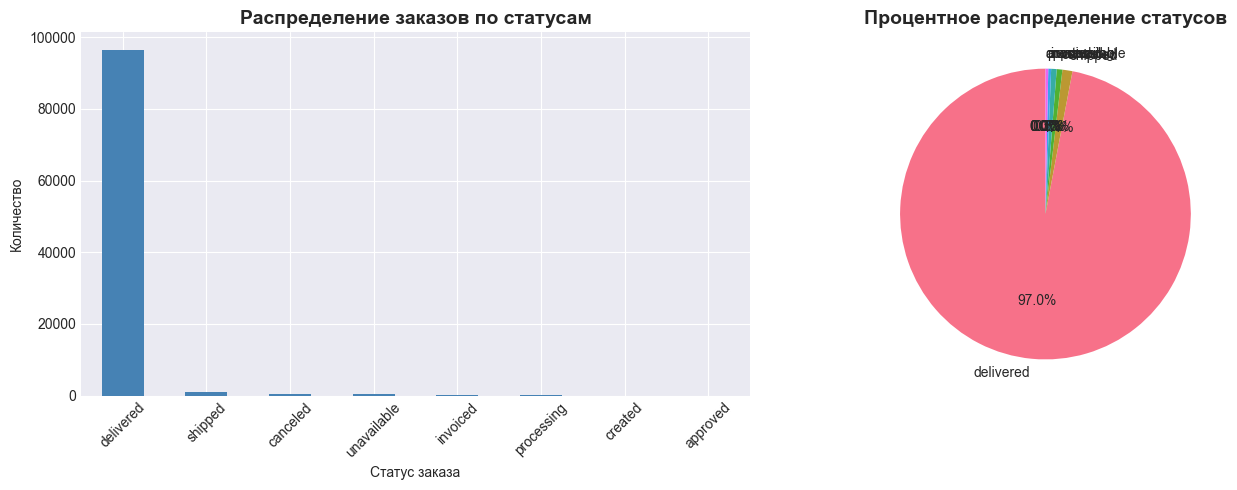

In [11]:
# Визуализация статусов заказов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
orders["order_status"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Распределение заказов по статусам", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Статус заказа")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=45)

# Круговая диаграмма
orders["order_status"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Процентное распределение статусов", fontsize=14, fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


In [12]:
# Анализ временных характеристик заказов
# Вычисляем время доставки для доставленных заказов
delivered_orders = orders[orders["order_status"] == "delivered"].copy()
delivered_orders = delivered_orders.dropna(
    subset=["order_delivered_customer_date", "order_purchase_timestamp"]
)

if len(delivered_orders) > 0:
    delivered_orders["delivery_time_days"] = (
        delivered_orders["order_delivered_customer_date"]
        - delivered_orders["order_purchase_timestamp"]
    ).dt.days

    delivered_orders["estimated_delivery_time_days"] = (
        delivered_orders["order_estimated_delivery_date"]
        - delivered_orders["order_purchase_timestamp"]
    ).dt.days

    delivered_orders["delay_days"] = (
        delivered_orders["delivery_time_days"]
        - delivered_orders["estimated_delivery_time_days"]
    )

    print("Статистика по времени доставки:")
    print(
        f"Среднее время доставки: {delivered_orders['delivery_time_days'].mean():.1f} дней"
    )
    print(
        f"Медианное время доставки: {delivered_orders['delivery_time_days'].median():.1f} дней"
    )
    print(f"Минимальное время: {delivered_orders['delivery_time_days'].min():.0f} дней")
    print(
        f"Максимальное время: {delivered_orders['delivery_time_days'].max():.0f} дней"
    )
    print(
        f"\nЗаказов с задержкой: {(delivered_orders['delay_days'] > 0).sum():,} "
        f"({(delivered_orders['delay_days'] > 0).mean() * 100:.1f}%)"
    )
    print(
        f"Средняя задержка: {delivered_orders[delivered_orders['delay_days'] > 0]['delay_days'].mean():.1f} дней"
    )


Статистика по времени доставки:
Среднее время доставки: 12.1 дней
Медианное время доставки: 10.0 дней
Минимальное время: 0 дней
Максимальное время: 209 дней

Заказов с задержкой: 7,307 (7.6%)
Средняя задержка: 10.1 дней


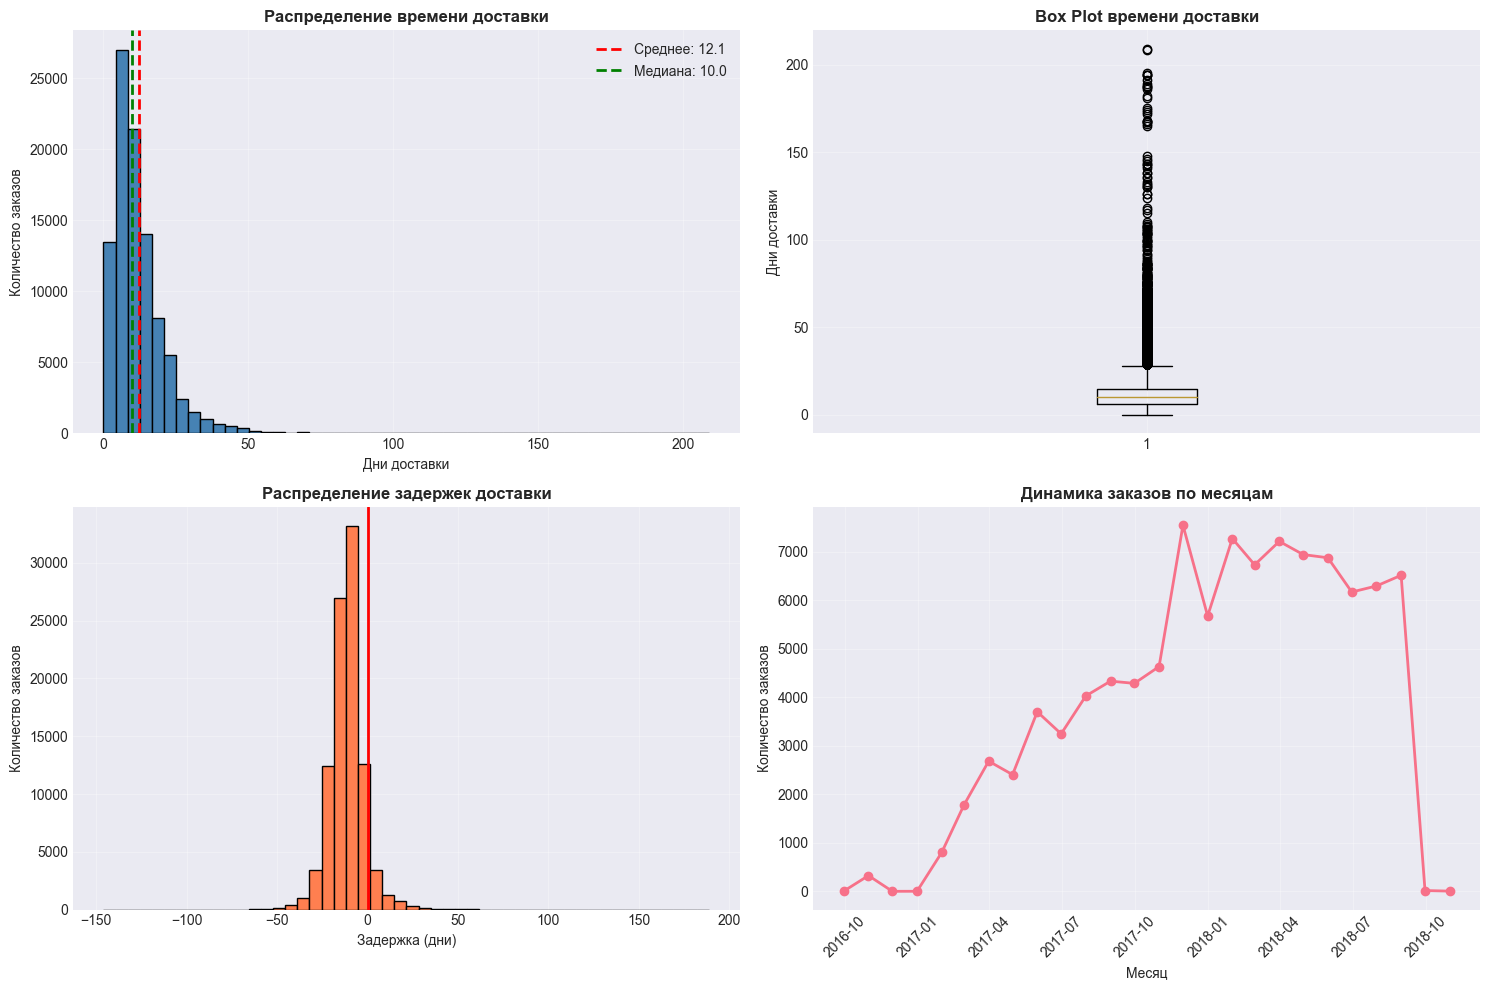

In [13]:
# Визуализация времени доставки
if len(delivered_orders) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Распределение времени доставки
    axes[0, 0].hist(
        delivered_orders["delivery_time_days"],
        bins=50,
        color="steelblue",
        edgecolor="black",
    )
    axes[0, 0].axvline(
        delivered_orders["delivery_time_days"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Среднее: {delivered_orders['delivery_time_days'].mean():.1f}",
    )
    axes[0, 0].axvline(
        delivered_orders["delivery_time_days"].median(),
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Медиана: {delivered_orders['delivery_time_days'].median():.1f}",
    )
    axes[0, 0].set_xlabel("Дни доставки")
    axes[0, 0].set_ylabel("Количество заказов")
    axes[0, 0].set_title("Распределение времени доставки", fontweight="bold")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Box plot времени доставки
    axes[0, 1].boxplot(delivered_orders["delivery_time_days"], vert=True)
    axes[0, 1].set_ylabel("Дни доставки")
    axes[0, 1].set_title("Box Plot времени доставки", fontweight="bold")
    axes[0, 1].grid(True, alpha=0.3)

    # Распределение задержек
    delay_data = delivered_orders["delay_days"]
    axes[1, 0].hist(delay_data, bins=50, color="coral", edgecolor="black")
    axes[1, 0].axvline(0, color="red", linestyle="-", linewidth=2)
    axes[1, 0].set_xlabel("Задержка (дни)")
    axes[1, 0].set_ylabel("Количество заказов")
    axes[1, 0].set_title("Распределение задержек доставки", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # Динамика заказов по времени
    orders["order_purchase_timestamp"] = pd.to_datetime(
        orders["order_purchase_timestamp"], errors="coerce"
    )
    orders_by_month = (
        orders.dropna(subset=["order_purchase_timestamp"])
        .set_index("order_purchase_timestamp")
        .resample("M")
        .size()
    )
    axes[1, 1].plot(
        orders_by_month.index,
        orders_by_month.values,
        marker="o",
        linewidth=2,
        markersize=6,
    )
    axes[1, 1].set_xlabel("Месяц")
    axes[1, 1].set_ylabel("Количество заказов")
    axes[1, 1].set_title("Динамика заказов по месяцам", fontweight="bold")
    axes[1, 1].tick_params(axis="x", rotation=45)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [ ]:
2.1**4

19.448100000000004

In [ ]:
delivered_orders["delivery_time_days"]

<Axes: xlabel='delivery_time_days', ylabel='Count'>

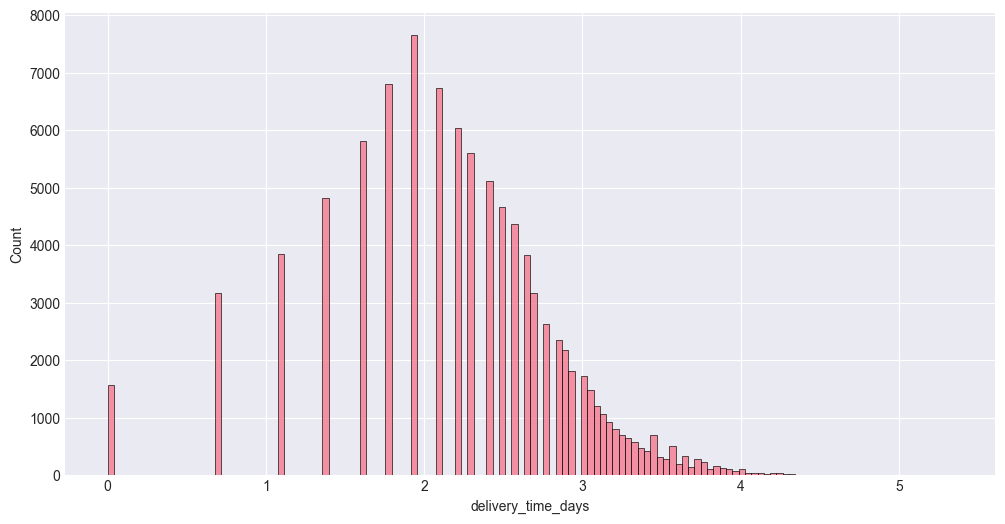

In [ ]:
sns.histplot(np.log(delivered_orders["delivery_time_days"]))

<Axes: xlabel='delivery_time_days', ylabel='Count'>

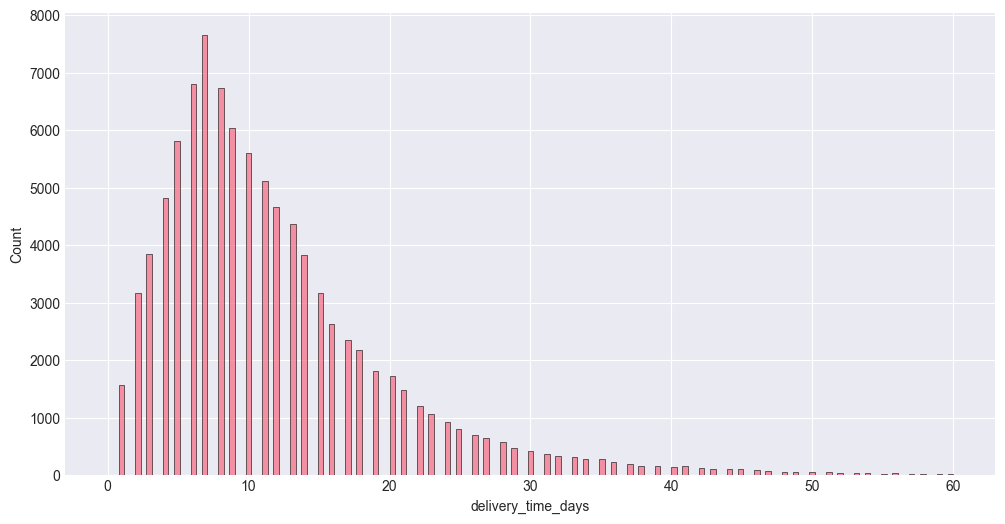

In [ ]:
sns.histplot(
    delivered_orders[np.log(delivered_orders["delivery_time_days"]) < 4.1][
        "delivery_time_days"
    ]
)

<Axes: >

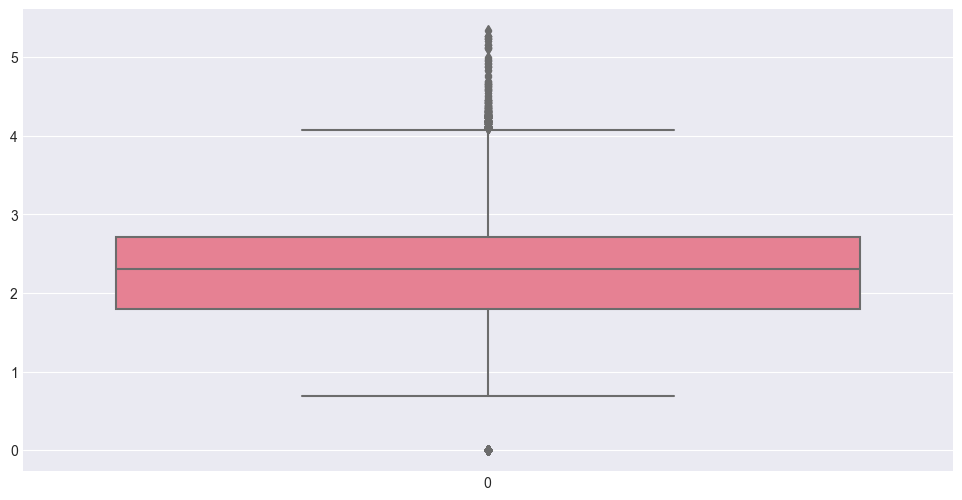

In [ ]:
sns.boxplot(np.log(delivered_orders["delivery_time_days"]))

## 5.2 Анализ клиентов (Customers)


In [14]:
# Анализ клиентов
customers = data["customers"].copy()

print("Анализ клиентов:")
print(f"Всего уникальных клиентов: {customers['customer_unique_id'].nunique():,}")
print(f"Всего записей: {len(customers):,}")
print(f"\nРаспределение по штатам (топ-10):")
print(customers["customer_state"].value_counts().head(10))
print(f"\nРаспределение по городам (топ-10):")
print(customers["customer_city"].value_counts().head(10))


Анализ клиентов:
Всего уникальных клиентов: 96,096
Всего записей: 99,441

Распределение по штатам (топ-10):
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

Распределение по городам (топ-10):
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


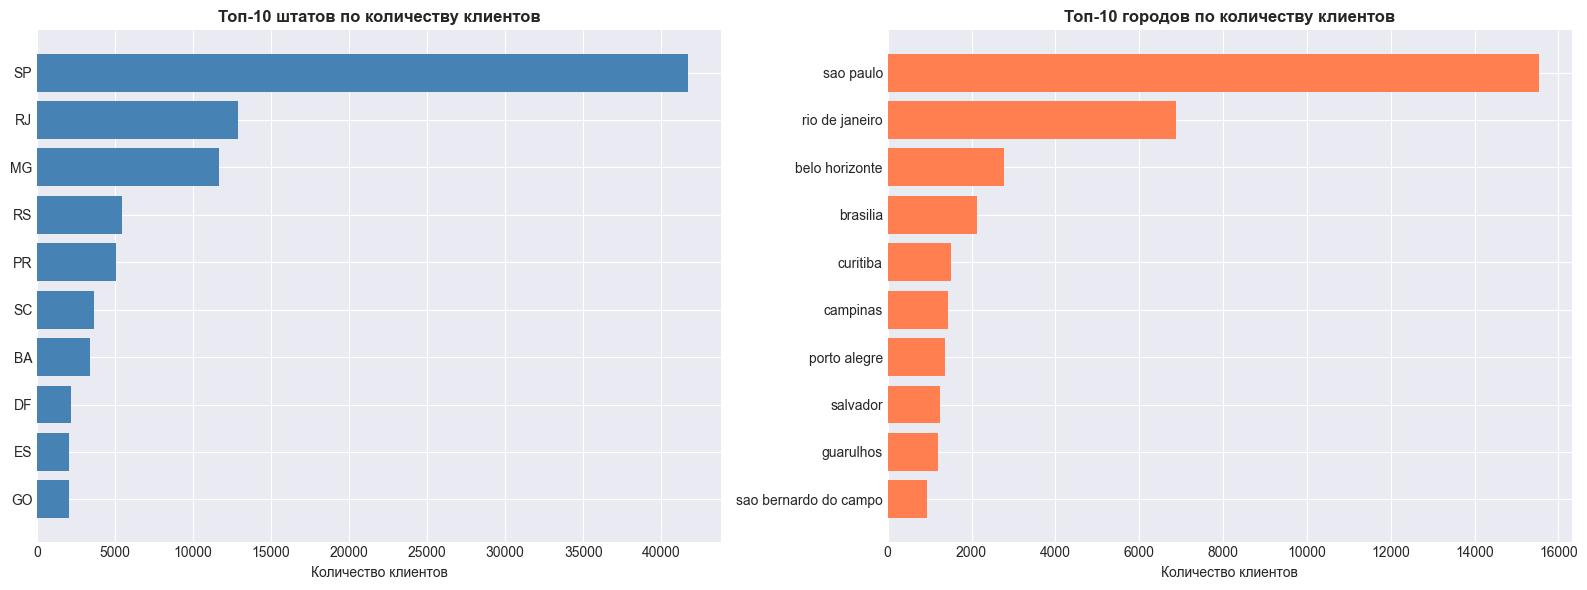

In [15]:
# Визуализация распределения клиентов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Топ-10 штатов
top_states = customers["customer_state"].value_counts().head(10)
axes[0].barh(top_states.index, top_states.values, color="steelblue")
axes[0].set_xlabel("Количество клиентов")
axes[0].set_title(
    "Топ-10 штатов по количеству клиентов", fontweight="bold", fontsize=12
)
axes[0].invert_yaxis()

# Топ-10 городов
top_cities = customers["customer_city"].value_counts().head(10)
axes[1].barh(top_cities.index, top_cities.values, color="coral")
axes[1].set_xlabel("Количество клиентов")
axes[1].set_title(
    "Топ-10 городов по количеству клиентов", fontweight="bold", fontsize=12
)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 5.3 Анализ товаров (Products)


In [16]:
# Анализ товаров
products = data["products"].copy()

# Загружаем переводы категорий
category_translation = data["category_translation"].copy()

# Объединяем с переводами
products = products.merge(category_translation, on="product_category_name", how="left")

print("Анализ товаров:")
print(f"Всего товаров: {len(products):,}")
print(f"Уникальных категорий: {products['product_category_name'].nunique()}")
print(f"\nТоп-10 категорий товаров:")
print(products["product_category_name_english"].value_counts().head(10))


Анализ товаров:
Всего товаров: 32,951
Уникальных категорий: 73

Топ-10 категорий товаров:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


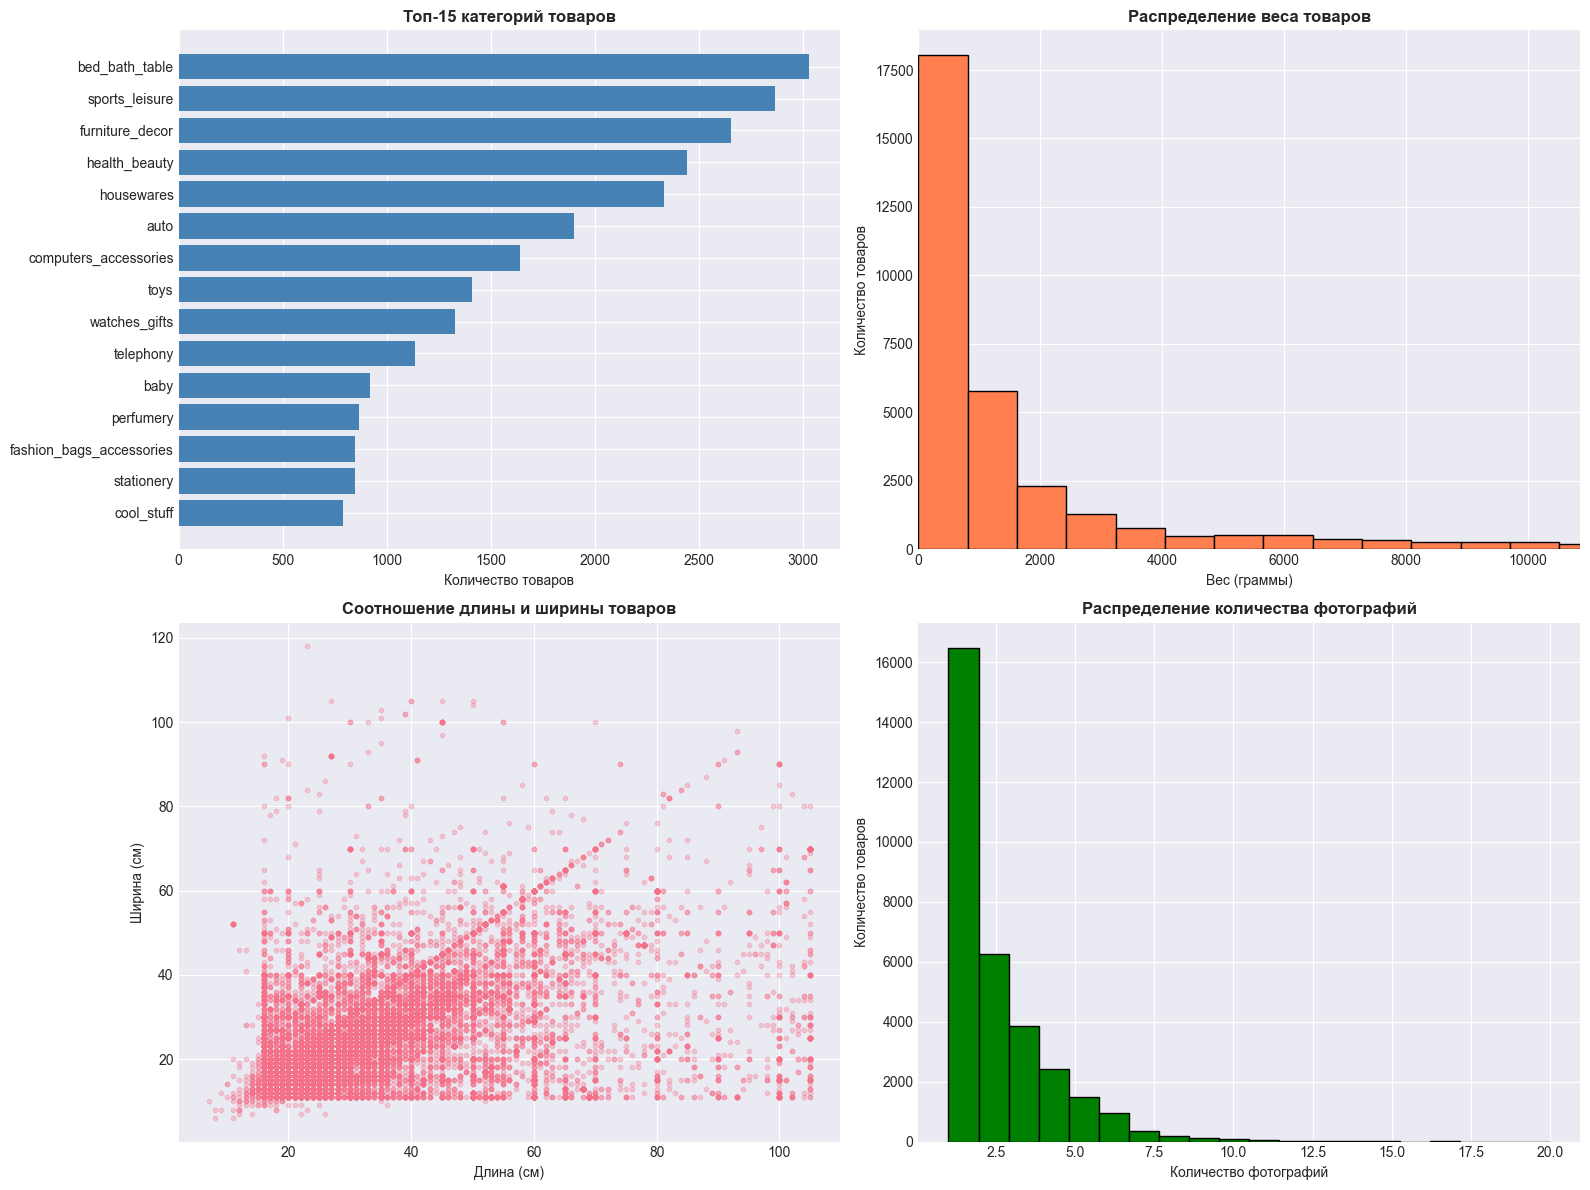

In [17]:
# Визуализация категорий товаров
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Топ-15 категорий
top_categories = products["product_category_name_english"].value_counts().head(15)
axes[0, 0].barh(top_categories.index, top_categories.values, color="steelblue")
axes[0, 0].set_xlabel("Количество товаров")
axes[0, 0].set_title("Топ-15 категорий товаров", fontweight="bold")
axes[0, 0].invert_yaxis()

# Распределение веса товаров
if "product_weight_g" in products.columns:
    axes[0, 1].hist(
        products["product_weight_g"].dropna(), bins=50, color="coral", edgecolor="black"
    )
    axes[0, 1].set_xlabel("Вес (граммы)")
    axes[0, 1].set_ylabel("Количество товаров")
    axes[0, 1].set_title("Распределение веса товаров", fontweight="bold")
    axes[0, 1].set_xlim(
        0, products["product_weight_g"].quantile(0.95)
    )  # Убираем выбросы

# Распределение размеров товаров
if "product_length_cm" in products.columns:
    axes[1, 0].scatter(
        products["product_length_cm"].dropna(),
        products["product_width_cm"].dropna(),
        alpha=0.3,
        s=10,
    )
    axes[1, 0].set_xlabel("Длина (см)")
    axes[1, 0].set_ylabel("Ширина (см)")
    axes[1, 0].set_title("Соотношение длины и ширины товаров", fontweight="bold")

# Распределение количества фотографий
if "product_photos_qty" in products.columns:
    axes[1, 1].hist(
        products["product_photos_qty"].dropna(),
        bins=20,
        color="green",
        edgecolor="black",
    )
    axes[1, 1].set_xlabel("Количество фотографий")
    axes[1, 1].set_ylabel("Количество товаров")
    axes[1, 1].set_title("Распределение количества фотографий", fontweight="bold")

plt.tight_layout()
plt.show()


## 5.4 Анализ платежей (Payments)


In [18]:
# Анализ платежей
payments = data["payments"].copy()

print("Анализ платежей:")
print(f"Всего записей о платежах: {len(payments):,}")
print(f"Уникальных заказов: {payments['order_id'].nunique():,}")
print(f"\nТипы платежей:")
print(payments["payment_type"].value_counts())
print(f"\nСтатистика по сумме платежей:")
print(payments["payment_value"].describe())
print(f"\nСтатистика по количеству рассрочек:")
print(payments["payment_installments"].describe())


Анализ платежей:
Всего записей о платежах: 103,886
Уникальных заказов: 99,440

Типы платежей:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Статистика по сумме платежей:
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Статистика по количеству рассрочек:
count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64


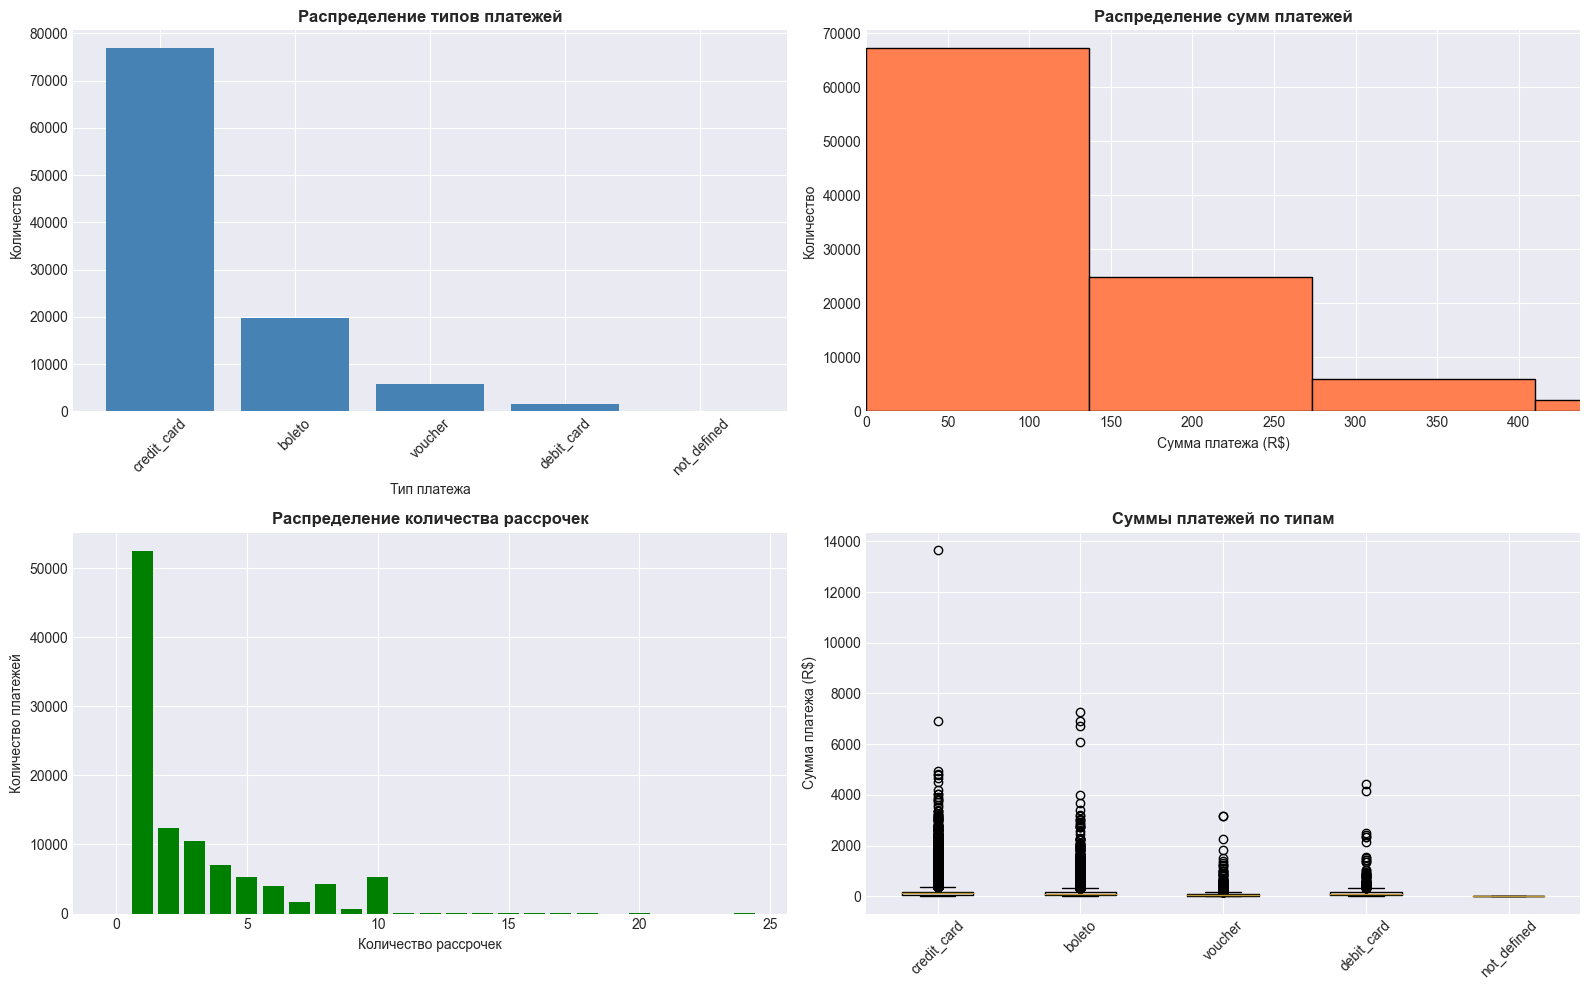

In [19]:
# Визуализация платежей
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Типы платежей
payment_types = payments["payment_type"].value_counts()
axes[0, 0].bar(payment_types.index, payment_types.values, color="steelblue")
axes[0, 0].set_xlabel("Тип платежа")
axes[0, 0].set_ylabel("Количество")
axes[0, 0].set_title("Распределение типов платежей", fontweight="bold")
axes[0, 0].tick_params(axis="x", rotation=45)

# Распределение сумм платежей
axes[0, 1].hist(payments["payment_value"], bins=100, color="coral", edgecolor="black")
axes[0, 1].set_xlabel("Сумма платежа (R$)")
axes[0, 1].set_ylabel("Количество")
axes[0, 1].set_title("Распределение сумм платежей", fontweight="bold")
axes[0, 1].set_xlim(0, payments["payment_value"].quantile(0.95))  # Убираем выбросы

# Распределение количества рассрочек
installments = payments["payment_installments"].value_counts().sort_index()
axes[1, 0].bar(installments.index, installments.values, color="green")
axes[1, 0].set_xlabel("Количество рассрочек")
axes[1, 0].set_ylabel("Количество платежей")
axes[1, 0].set_title("Распределение количества рассрочек", fontweight="bold")

# Box plot сумм платежей по типам
payment_types_list = payments["payment_type"].unique()
box_data = [
    payments[payments["payment_type"] == pt]["payment_value"].values
    for pt in payment_types_list
]
axes[1, 1].boxplot(box_data, labels=payment_types_list)
axes[1, 1].set_ylabel("Сумма платежа (R$)")
axes[1, 1].set_title("Суммы платежей по типам", fontweight="bold")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# Этап 6: Объединенный анализ (Joining Data)

## Цель:
Объединить данные из разных таблиц для более глубокого анализа


In [20]:
# Создаем объединенный датасет для анализа заказов
# Шаг 1: Объединяем заказы с элементами заказов
orders_items = data["orders"].merge(data["order_items"], on="order_id", how="inner")

# Шаг 2: Добавляем информацию о товарах
orders_items_products = orders_items.merge(
    data["products"], on="product_id", how="left"
)

# Шаг 3: Добавляем переводы категорий
orders_items_products = orders_items_products.merge(
    data["category_translation"], on="product_category_name", how="left"
)

# Шаг 4: Добавляем информацию о платежах
# Сначала агрегируем платежи по заказам (суммируем все платежи по заказу)
payments_agg = (
    data["payments"]
    .groupby("order_id")
    .agg(
        {
            "payment_value": "sum",
            "payment_type": lambda x: ", ".join(x.unique()),  # Все типы платежей
            "payment_installments": "max",  # Максимальное количество рассрочек
        }
    )
    .reset_index()
)

orders_full = orders_items_products.merge(payments_agg, on="order_id", how="left")

# Шаг 5: Добавляем информацию о клиентах
orders_full = orders_full.merge(data["customers"], on="customer_id", how="left")

print("Объединенный датасет создан!")
print(f"Размер: {orders_full.shape[0]:,} строк × {orders_full.shape[1]} столбцов")
print(f"\nСтолбцы:")
print(orders_full.columns.tolist())


Объединенный датасет создан!
Размер: 112,650 строк × 30 столбцов

Столбцы:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_value', 'payment_type', 'payment_installments', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


## 6.1 Анализ выручки и продаж


In [21]:
# Вычисляем общую стоимость заказа (цена товара + доставка)
orders_full["total_order_value"] = orders_full["price"] + orders_full["freight_value"]

print("Анализ выручки:")
print(f"Общая выручка: R$ {orders_full['total_order_value'].sum():,.2f}")
print(f"Средний чек: R$ {orders_full['total_order_value'].mean():.2f}")
print(f"Медианный чек: R$ {orders_full['total_order_value'].median():.2f}")
print(f"\nСтатистика по ценам товаров:")
print(orders_full["price"].describe())
print(f"\nСтатистика по стоимости доставки:")
print(orders_full["freight_value"].describe())


Анализ выручки:
Общая выручка: R$ 15,843,553.24
Средний чек: R$ 140.64
Медианный чек: R$ 92.32

Статистика по ценам товаров:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Статистика по стоимости доставки:
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


In [22]:
# Анализ выручки по категориям
revenue_by_category = (
    orders_full.groupby("product_category_name_english")
    .agg({"total_order_value": "sum", "order_id": "nunique", "price": "mean"})
    .reset_index()
)
revenue_by_category.columns = ["category", "total_revenue", "orders_count", "avg_price"]
revenue_by_category = revenue_by_category.sort_values("total_revenue", ascending=False)

print("Топ-15 категорий по выручке:")
display(revenue_by_category.head(15))


Топ-15 категорий по выручке:


,category,total_revenue,orders_count,avg_price
43,health_beauty,1441248.07,8836,130.163531
70,watches_gifts,1305541.61,5624,201.135984
7,bed_bath_table,1241681.72,9417,93.296327
65,sports_leisure,1156656.48,7720,114.344285
15,computers_accessories,1059272.40,6689,116.513903
39,furniture_decor,902511.79,6449,87.564494
49,housewares,778397.77,5884,90.788148
20,cool_stuff,719329.95,3632,167.357969
5,auto,685384.32,3897,139.957523
42,garden_tools,584219.21,3518,111.630196


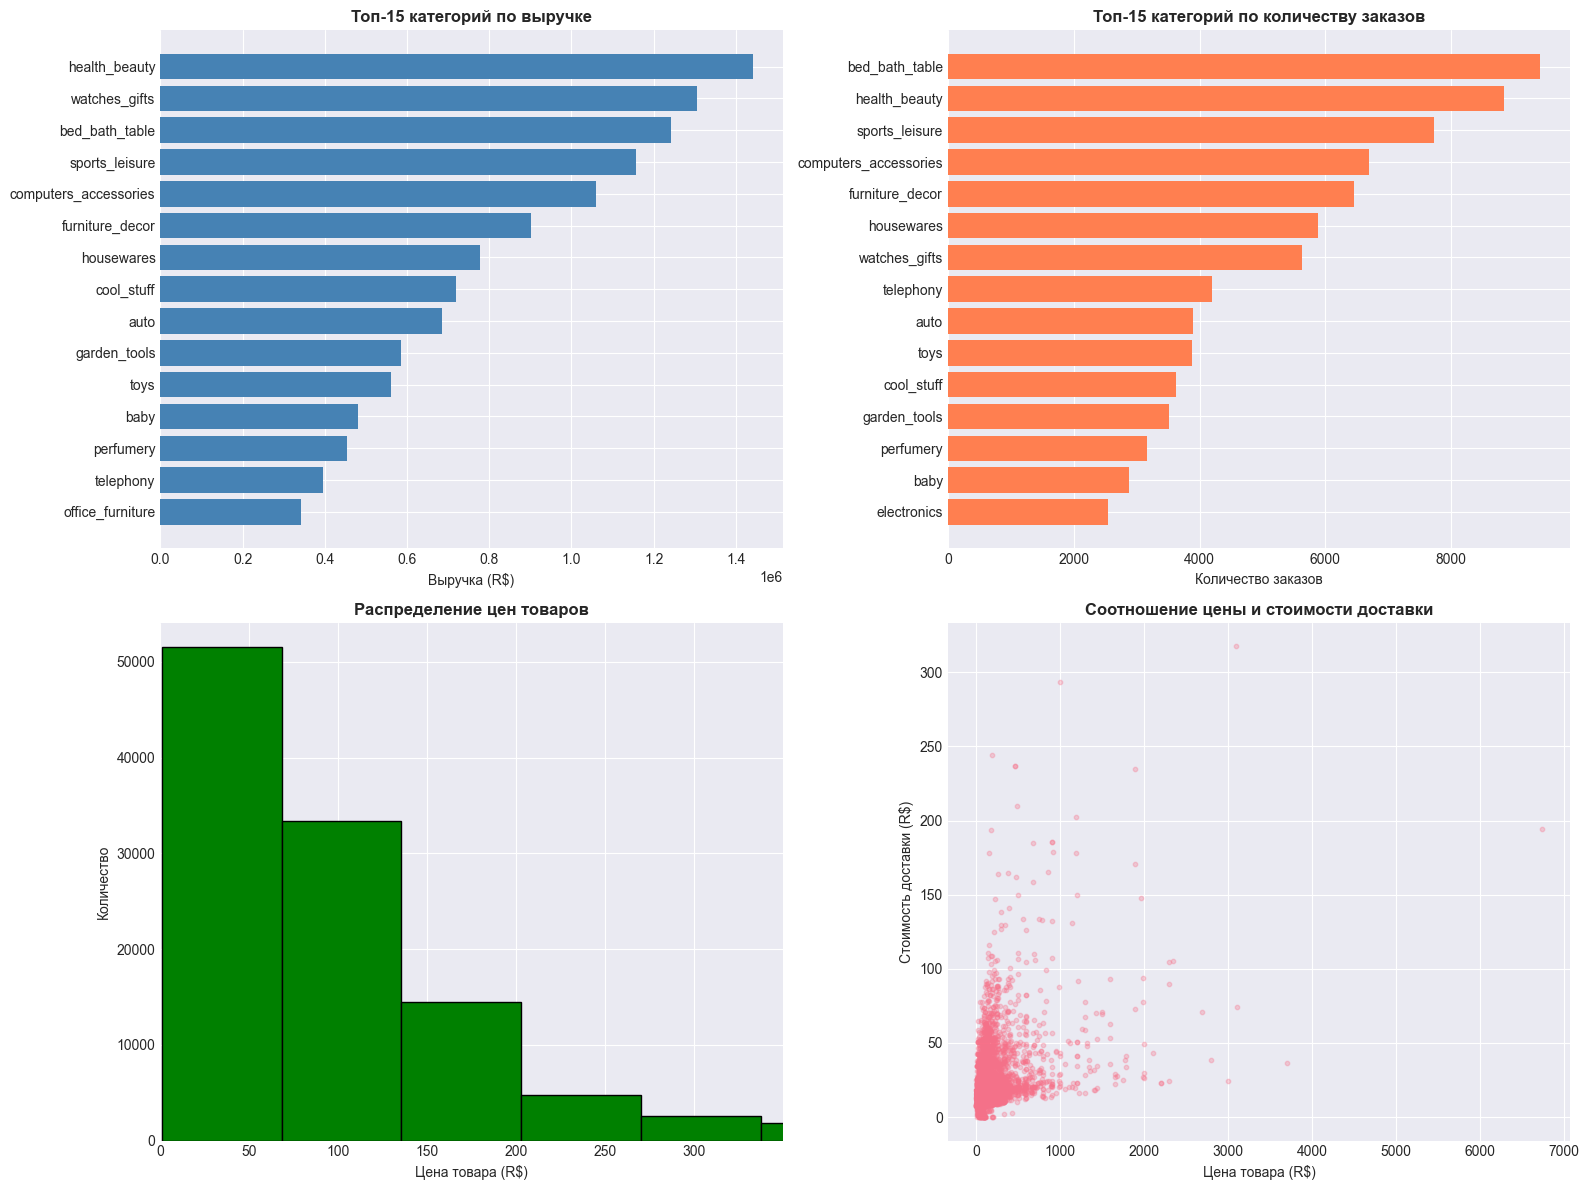

In [23]:
# Визуализация выручки по категориям
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Топ-15 категорий по выручке
top_revenue = revenue_by_category.head(15)
axes[0, 0].barh(
    top_revenue["category"], top_revenue["total_revenue"], color="steelblue"
)
axes[0, 0].set_xlabel("Выручка (R$)")
axes[0, 0].set_title("Топ-15 категорий по выручке", fontweight="bold")
axes[0, 0].invert_yaxis()

# Топ-15 категорий по количеству заказов
top_orders = revenue_by_category.sort_values("orders_count", ascending=False).head(15)
axes[0, 1].barh(top_orders["category"], top_orders["orders_count"], color="coral")
axes[0, 1].set_xlabel("Количество заказов")
axes[0, 1].set_title("Топ-15 категорий по количеству заказов", fontweight="bold")
axes[0, 1].invert_yaxis()

# Распределение цен
axes[1, 0].hist(orders_full["price"], bins=100, color="green", edgecolor="black")
axes[1, 0].set_xlabel("Цена товара (R$)")
axes[1, 0].set_ylabel("Количество")
axes[1, 0].set_title("Распределение цен товаров", fontweight="bold")
axes[1, 0].set_xlim(0, orders_full["price"].quantile(0.95))

# Соотношение цены и стоимости доставки
sample = orders_full.sample(min(10000, len(orders_full)))
axes[1, 1].scatter(sample["price"], sample["freight_value"], alpha=0.3, s=10)
axes[1, 1].set_xlabel("Цена товара (R$)")
axes[1, 1].set_ylabel("Стоимость доставки (R$)")
axes[1, 1].set_title("Соотношение цены и стоимости доставки", fontweight="bold")

plt.tight_layout()
plt.show()


## 6.2 Анализ по регионам


In [24]:
# Анализ продаж по штатам
sales_by_state = (
    orders_full.groupby("customer_state")
    .agg({"total_order_value": "sum", "order_id": "nunique", "price": "mean"})
    .reset_index()
)
sales_by_state.columns = ["state", "total_revenue", "orders_count", "avg_price"]
sales_by_state = sales_by_state.sort_values("total_revenue", ascending=False)

print("Топ-10 штатов по выручке:")
display(sales_by_state.head(10))


Топ-10 штатов по выручке:


,state,total_revenue,orders_count,avg_price
25,SP,5921678.12,41375,109.653629
18,RJ,2129681.98,12762,125.117818
10,MG,1856161.49,11544,120.748574
22,RS,885826.76,5432,120.337453
17,PR,800935.44,4998,119.004139
4,BA,611506.67,3358,134.601208
23,SC,610213.60,3612,124.653578
6,DF,353229.44,2125,125.770549
8,GO,347706.93,2007,126.271732
7,ES,324801.91,2025,121.913701


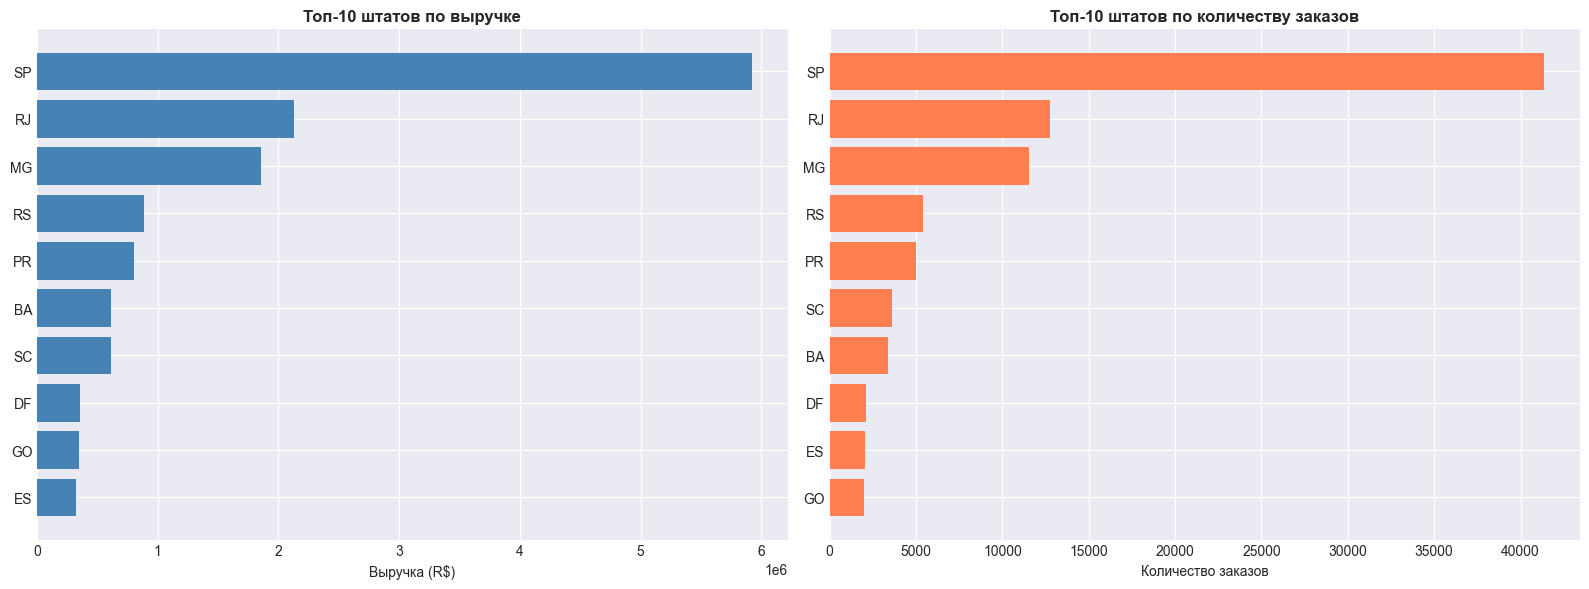

In [25]:
# Визуализация продаж по штатам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Топ-10 штатов по выручке
top_states_revenue = sales_by_state.head(10)
axes[0].barh(
    top_states_revenue["state"], top_states_revenue["total_revenue"], color="steelblue"
)
axes[0].set_xlabel("Выручка (R$)")
axes[0].set_title("Топ-10 штатов по выручке", fontweight="bold")
axes[0].invert_yaxis()

# Топ-10 штатов по количеству заказов
top_states_orders = sales_by_state.sort_values("orders_count", ascending=False).head(10)
axes[1].barh(
    top_states_orders["state"], top_states_orders["orders_count"], color="coral"
)
axes[1].set_xlabel("Количество заказов")
axes[1].set_title("Топ-10 штатов по количеству заказов", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 6.3 Временной анализ продаж


In [26]:
# Анализ продаж по времени
orders_full["order_purchase_timestamp"] = pd.to_datetime(
    orders_full["order_purchase_timestamp"], errors="coerce"
)

# Агрегируем по месяцам
orders_full["year_month"] = orders_full["order_purchase_timestamp"].dt.to_period("M")
monthly_sales = (
    orders_full.groupby("year_month")
    .agg({"total_order_value": "sum", "order_id": "nunique", "price": "mean"})
    .reset_index()
)
monthly_sales.columns = ["month", "revenue", "orders", "avg_price"]
monthly_sales["month"] = monthly_sales["month"].astype(str)

print("Динамика продаж по месяцам:")
display(monthly_sales)


Динамика продаж по месяцам:


,month,revenue,orders,avg_price
0,2016-09,354.75,3,44.560000
1,2016-10,56808.84,308,136.384738
2,2016-12,19.62,1,10.900000
3,2017-01,137188.49,789,125.982063
4,2017-02,286280.62,1733,126.757058
5,2017-03,432048.59,2641,124.781433
6,2017-04,412422.24,2391,134.101054
7,2017-05,586190.95,3660,122.357626
8,2017-06,502963.04,3217,120.859224
9,2017-07,584971.62,3969,110.208338


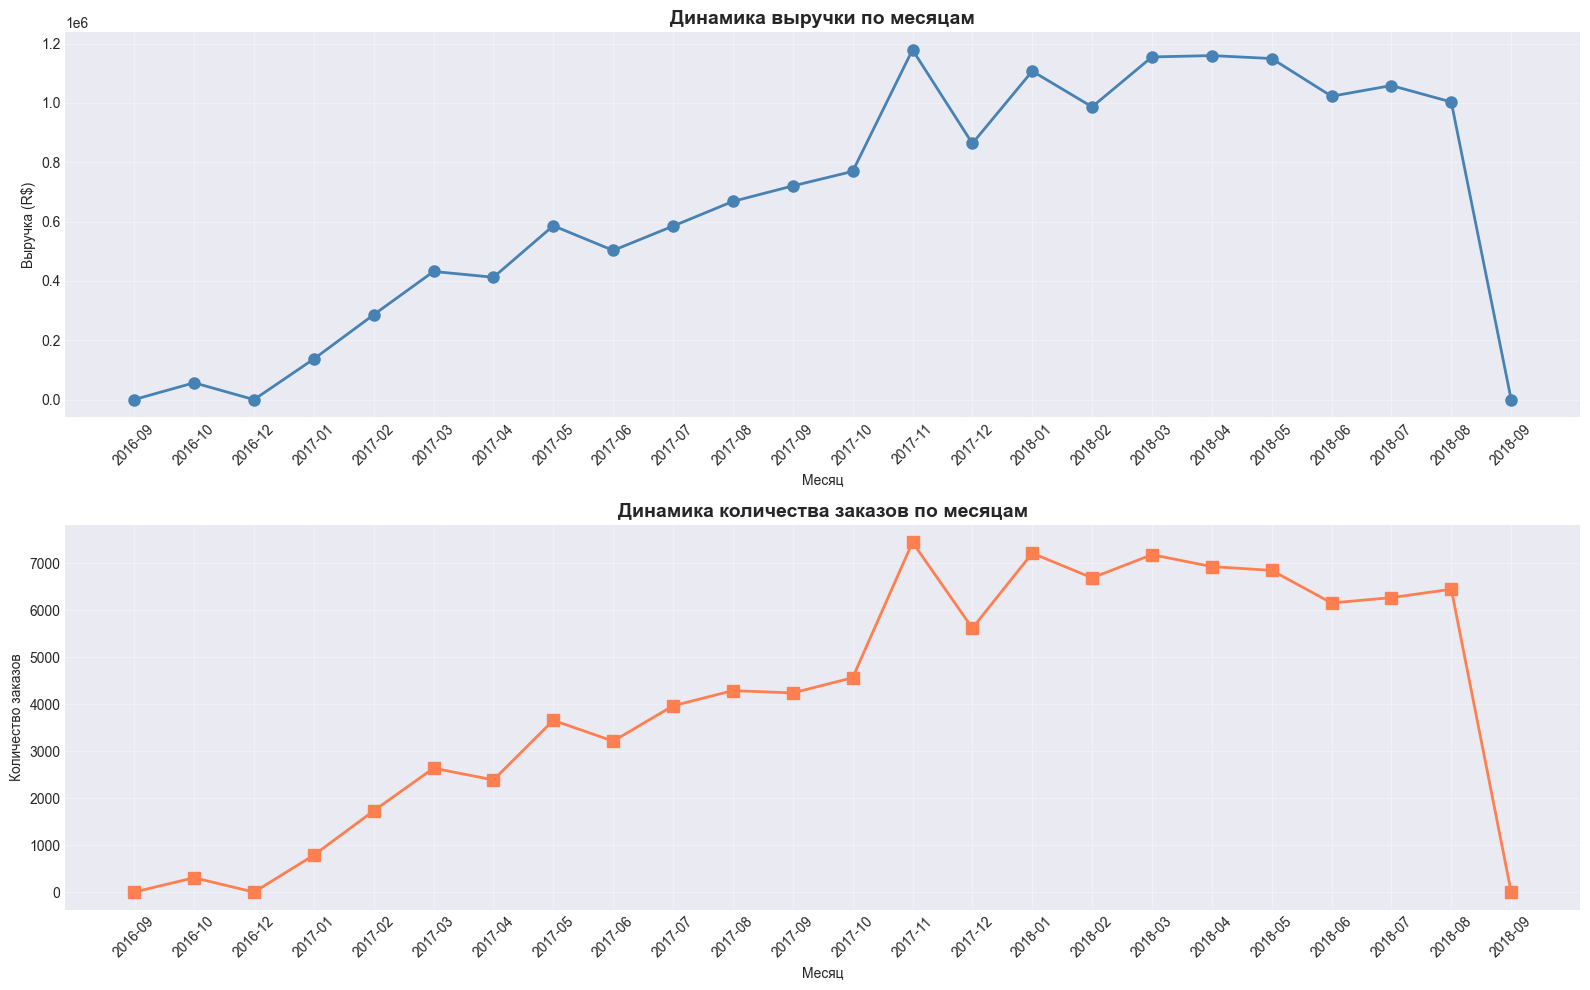

In [27]:
# Визуализация временных трендов
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Динамика выручки
axes[0].plot(
    monthly_sales["month"],
    monthly_sales["revenue"],
    marker="o",
    linewidth=2,
    markersize=8,
    color="steelblue",
)
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Выручка (R$)")
axes[0].set_title("Динамика выручки по месяцам", fontweight="bold", fontsize=14)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)

# Динамика количества заказов
axes[1].plot(
    monthly_sales["month"],
    monthly_sales["orders"],
    marker="s",
    linewidth=2,
    markersize=8,
    color="coral",
)
axes[1].set_xlabel("Месяц")
axes[1].set_ylabel("Количество заказов")
axes[1].set_title(
    "Динамика количества заказов по месяцам", fontweight="bold", fontsize=14
)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
# Анализ по дням недели и часам
orders_full["day_of_week"] = orders_full["order_purchase_timestamp"].dt.day_name()
orders_full["hour"] = orders_full["order_purchase_timestamp"].dt.hour

# Продажи по дням недели
sales_by_day = (
    orders_full.groupby("day_of_week")
    .agg({"total_order_value": "sum", "order_id": "nunique"})
    .reset_index()
)
sales_by_day.columns = ["day", "revenue", "orders"]

# Порядок дней недели
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
sales_by_day["day"] = pd.Categorical(
    sales_by_day["day"], categories=day_order, ordered=True
)
sales_by_day = sales_by_day.sort_values("day")

# Продажи по часам
sales_by_hour = (
    orders_full.groupby("hour")
    .agg({"total_order_value": "sum", "order_id": "nunique"})
    .reset_index()
)
sales_by_hour.columns = ["hour", "revenue", "orders"]

print("Продажи по дням недели:")
display(sales_by_day)
print("\nПродажи по часам (топ-10):")
display(sales_by_hour.sort_values("revenue", ascending=False).head(10))


Продажи по дням недели:


,day,revenue,orders
1,Monday,2600533.82,16068
5,Tuesday,2532228.11,15831
6,Wednesday,2466682.13,15425
4,Thursday,2351584.20,14639
0,Friday,2281931.02,14002
2,Saturday,1752075.49,10813
3,Sunday,1858518.47,11888



Продажи по часам (топ-10):


,hour,revenue,orders
14,14,1100743.07,6521
16,16,1090233.44,6628
15,15,1052986.78,6397
11,11,1023074.93,6528
13,13,1015875.62,6461
20,20,995339.27,6144
12,12,986082.17,5947
17,17,979469.54,6105
10,10,975972.35,6112
21,21,975604.70,6177


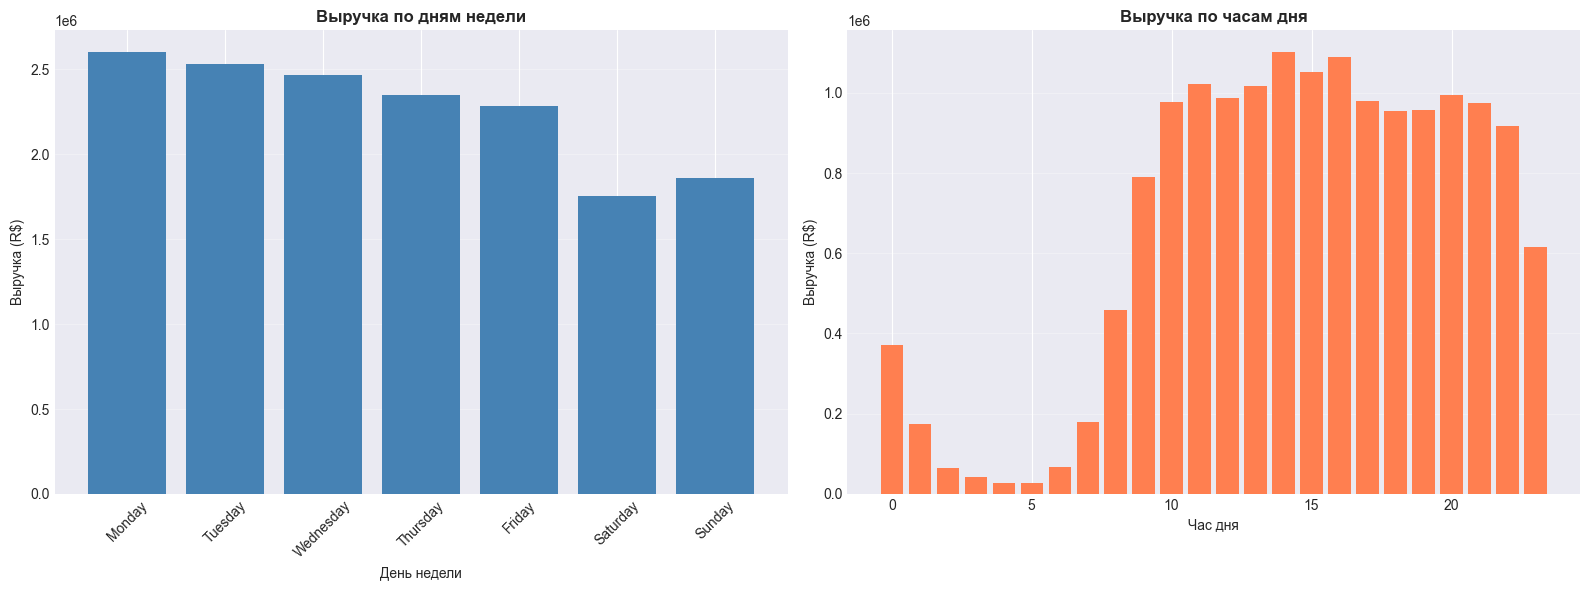

In [29]:
# Визуализация продаж по дням недели и часам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# По дням недели
axes[0].bar(sales_by_day["day"], sales_by_day["revenue"], color="steelblue")
axes[0].set_xlabel("День недели")
axes[0].set_ylabel("Выручка (R$)")
axes[0].set_title("Выручка по дням недели", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

# По часам
axes[1].bar(sales_by_hour["hour"], sales_by_hour["revenue"], color="coral")
axes[1].set_xlabel("Час дня")
axes[1].set_ylabel("Выручка (R$)")
axes[1].set_title("Выручка по часам дня", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


# Этап 7: Корреляционный анализ

## Цель:
Найти взаимосвязи между числовыми переменными


In [30]:
# Выбираем числовые столбцы для корреляционного анализа
numerical_cols = orders_full.select_dtypes(include=[np.number]).columns.tolist()

# Убираем ID столбцы и другие нерелевантные
correlation_cols = [
    col
    for col in numerical_cols
    if col not in ["order_item_id", "payment_sequential"]
    and not col.startswith("customer_zip")
]

# Создаем матрицу корреляций
correlation_matrix = orders_full[correlation_cols].corr()

print("Корреляционная матрица:")
display(correlation_matrix)


Корреляционная матрица:


,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value,payment_installments,total_order_value,hour
price,1.000000,0.414204,0.017001,0.198166,0.051848,0.338819,0.145811,0.223602,0.172467,0.761235,0.285593,0.997151,0.007607
freight_value,0.414204,1.000000,0.023611,0.093855,0.022259,0.610420,0.309086,0.391831,0.323777,0.386453,0.192770,0.481681,0.005932
product_name_lenght,0.017001,0.023611,1.000000,0.091524,0.145904,0.022731,0.060447,-0.028170,0.064442,0.002254,0.020483,0.018329,0.000395
product_description_lenght,0.198166,0.093855,0.091524,1.000000,0.118087,0.059710,0.005971,0.072724,-0.068419,0.159276,0.036357,0.198573,-0.008712
product_photos_qty,0.051848,0.022259,0.145904,0.118087,1.000000,0.022667,0.047503,-0.033399,0.010367,0.009791,-0.000272,0.051763,0.003694
product_weight_g,0.338819,0.610420,0.022731,0.059710,0.022667,1.000000,0.460919,0.583277,0.506609,0.316895,0.186941,0.376823,0.009361
product_length_cm,0.145811,0.309086,0.060447,0.005971,0.047503,0.460919,1.000000,0.192895,0.532537,0.146373,0.125084,0.166013,0.006896
product_height_cm,0.223602,0.391831,-0.028170,0.072724,-0.033399,0.583277,0.192895,1.000000,0.281224,0.224190,0.127021,0.247770,0.006090
product_width_cm,0.172467,0.323777,0.064442,-0.068419,0.010367,0.506609,0.532537,0.281224,1.000000,0.156538,0.145728,0.192895,0.011250
payment_value,0.761235,0.386453,0.002254,0.159276,0.009791,0.316895,0.146373,0.224190,0.156538,1.000000,0.263158,0.764962,-0.003891


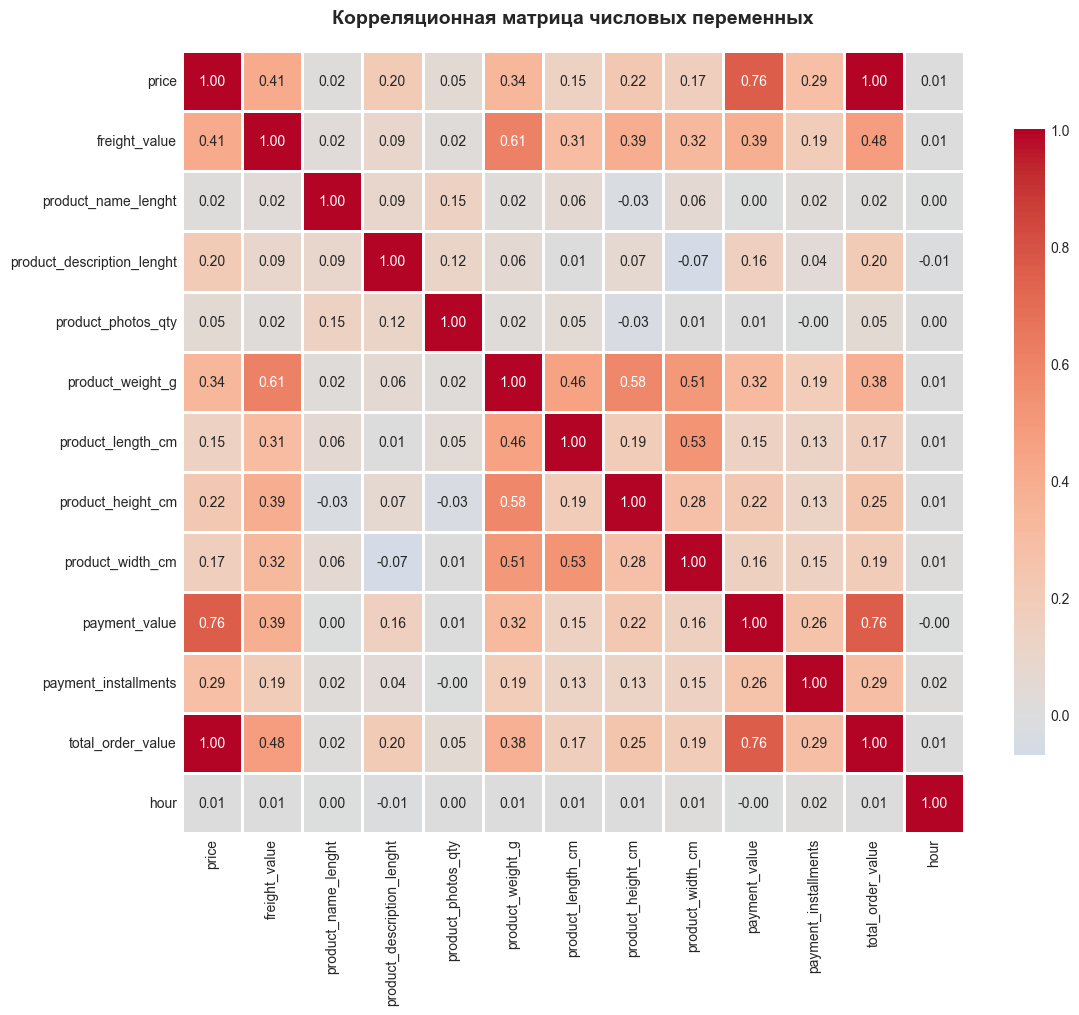

In [31]:
# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title(
    "Корреляционная матрица числовых переменных", fontweight="bold", fontsize=14, pad=20
)
plt.tight_layout()
plt.show()


# Этап 8: Анализ отзывов (Reviews)

## Цель:
Понять удовлетворенность клиентов


In [32]:
# Анализ отзывов
reviews = data["reviews"].copy()

# Преобразуем даты
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"], errors="coerce"
)
reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"], errors="coerce"
)

print("Анализ отзывов:")
print(f"Всего отзывов: {len(reviews):,}")
print(f"\nРаспределение оценок:")
print(reviews["review_score"].value_counts().sort_index())
print(f"\nСредняя оценка: {reviews['review_score'].mean():.2f}")
print(f"Медианная оценка: {reviews['review_score'].median():.0f}")


Анализ отзывов:
Всего отзывов: 99,224

Распределение оценок:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Средняя оценка: 4.09
Медианная оценка: 5


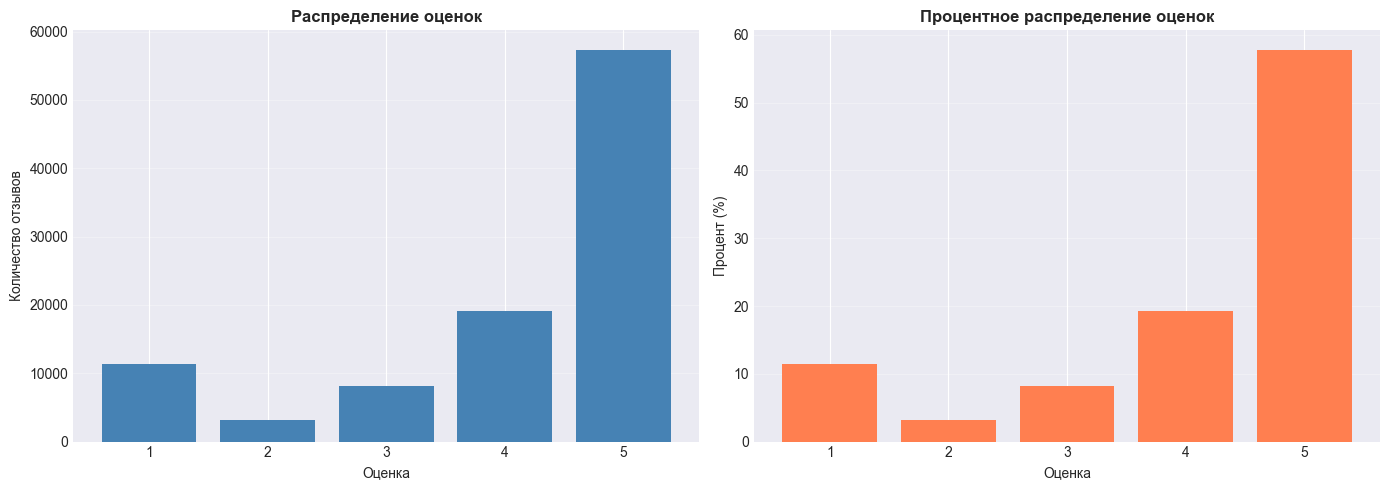

In [33]:
# Визуализация отзывов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение оценок
score_counts = reviews["review_score"].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color="steelblue")
axes[0].set_xlabel("Оценка")
axes[0].set_ylabel("Количество отзывов")
axes[0].set_title("Распределение оценок", fontweight="bold")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(True, alpha=0.3, axis="y")

# Процентное распределение
score_pct = reviews["review_score"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(score_pct.index, score_pct.values, color="coral")
axes[1].set_xlabel("Оценка")
axes[1].set_ylabel("Процент (%)")
axes[1].set_title("Процентное распределение оценок", fontweight="bold")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [34]:
# Объединяем отзывы с заказами для анализа
orders_with_reviews = orders_full.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="left"
)

# Анализ оценок по категориям
reviews_by_category = (
    orders_with_reviews.groupby("product_category_name_english")
    .agg({"review_score": "mean", "order_id": "nunique"})
    .reset_index()
)
reviews_by_category.columns = ["category", "avg_score", "orders_count"]
reviews_by_category = reviews_by_category[
    reviews_by_category["orders_count"] >= 100
]  # Минимум 100 заказов
reviews_by_category = reviews_by_category.sort_values("avg_score", ascending=False)

print("Топ-15 категорий по средней оценке (минимум 100 заказов):")
display(reviews_by_category.head(15))
print("\nКатегории с самыми низкими оценками:")
display(reviews_by_category.tail(10))


Топ-15 категорий по средней оценке (минимум 100 заказов):


,category,avg_score,orders_count
8,books_general_interest,4.446266,512
10,books_technical,4.368421,260
37,food_drink,4.315412,227
53,luggage_accessories,4.315257,1034
31,fashion_shoes,4.233716,240
36,food,4.218182,450
66,stationery,4.193857,2311
60,pet_shop,4.185147,1710
14,computers,4.175000,181
44,home_appliances,4.172457,764



Категории с самыми низкими оценками:


,category,avg_score,orders_count
15,computers_accessories,3.930819,6689
40,furniture_living_room,3.904382,422
39,furniture_decor,3.903493,6449
7,bed_bath_table,3.895663,9417
19,construction_tools_safety,3.844560,167
47,home_confort,3.829885,397
4,audio,3.825485,350
34,fixed_telephony,3.683206,217
30,fashion_male_clothing,3.641221,112
57,office_furniture,3.493183,1273


# Этап 9: Выявление аномалий и выбросов

## Цель:
Найти необычные значения, которые могут требовать внимания


In [35]:
# Функция для обнаружения выбросов методом IQR
def detect_outliers_iqr(df, column):
    """Обнаруживает выбросы используя метод межквартильного размаха (IQR)"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return {
        "outliers_count": len(outliers),
        "outliers_pct": (len(outliers) / len(df)) * 100,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers": outliers,
    }


# Проверяем выбросы в ключевых числовых столбцах
outlier_columns = ["price", "freight_value", "payment_value", "product_weight_g"]

print("Анализ выбросов:")
print("=" * 60)

for col in outlier_columns:
    if col in orders_full.columns:
        result = detect_outliers_iqr(orders_full, col)
        print(f"\n{col}:")
        print(
            f"  Выбросов: {result['outliers_count']:,} ({result['outliers_pct']:.2f}%)"
        )
        print(f"  Границы: [{result['lower_bound']:.2f}, {result['upper_bound']:.2f}]")
        if result["outliers_count"] > 0:
            print(f"  Минимальный выброс: {result['outliers'][col].min():.2f}")
            print(f"  Максимальный выброс: {result['outliers'][col].max():.2f}")


Анализ выбросов:

price:
  Выбросов: 8,427 (7.48%)
  Границы: [-102.60, 277.40]
  Минимальный выброс: 277.45
  Максимальный выброс: 6735.00

freight_value:
  Выбросов: 12,134 (10.77%)
  Границы: [0.98, 33.25]
  Минимальный выброс: 0.00
  Максимальный выброс: 409.68

payment_value:
  Выбросов: 9,200 (8.17%)
  Границы: [-128.91, 389.97]
  Минимальный выброс: 389.98
  Максимальный выброс: 13664.08

product_weight_g:
  Выбросов: 15,807 (14.03%)
  Границы: [-1950.00, 4050.00]
  Минимальный выброс: 4073.00
  Максимальный выброс: 40425.00


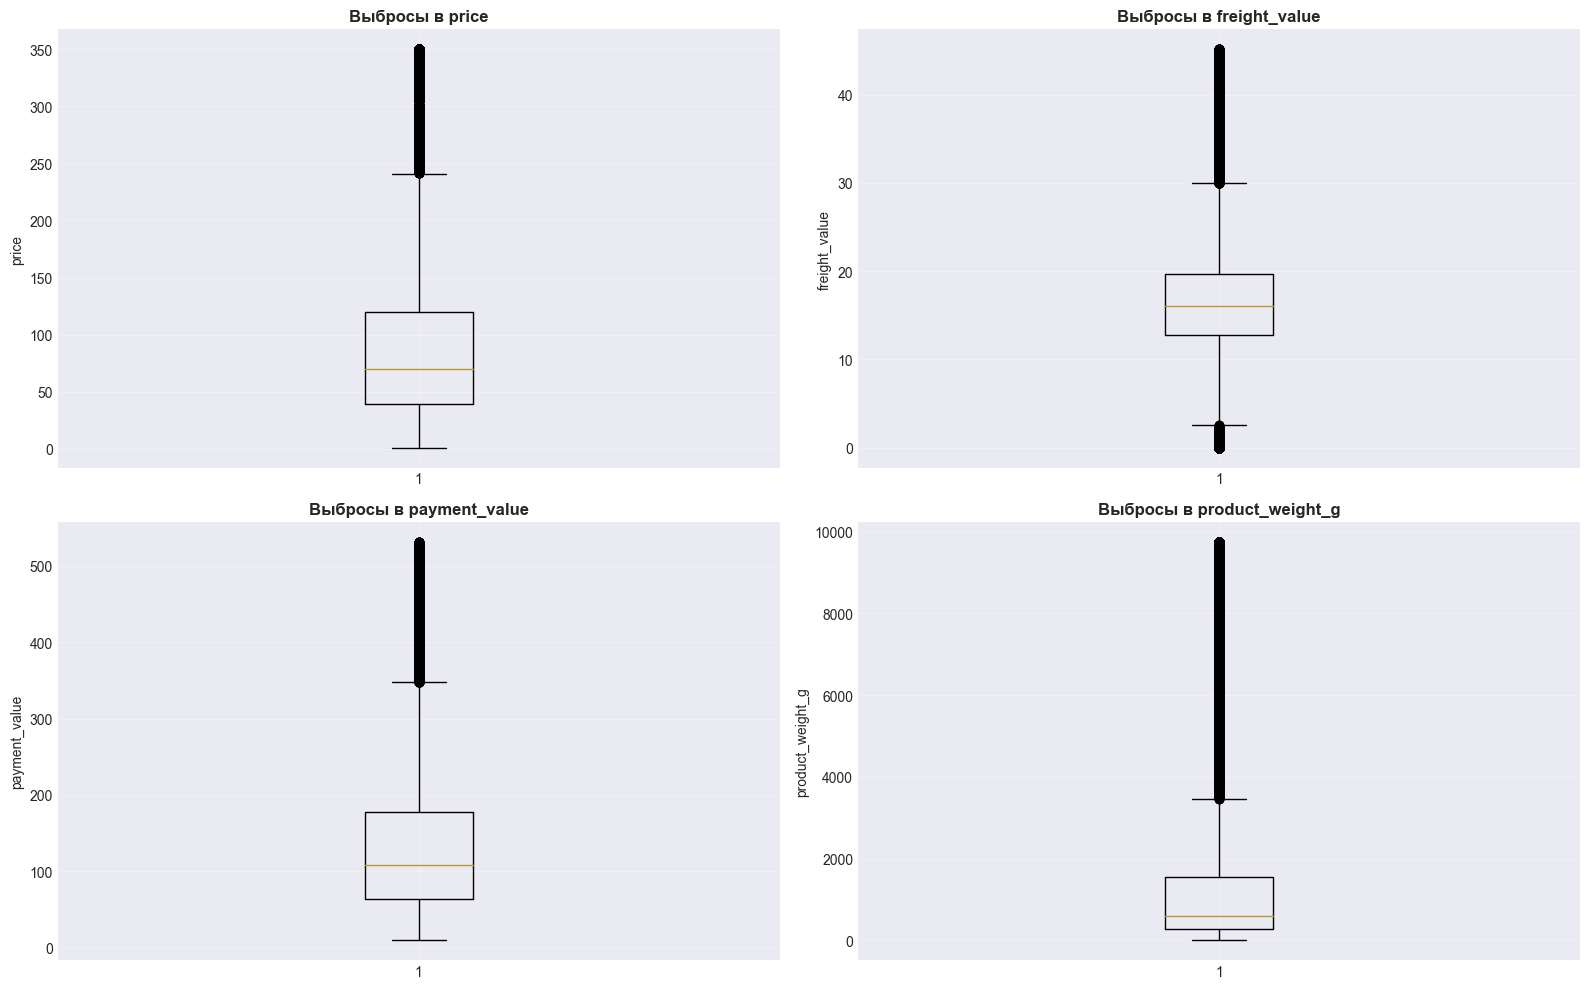

In [36]:
# Визуализация выбросов
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

outlier_cols_to_plot = ["price", "freight_value", "payment_value", "product_weight_g"]

for idx, col in enumerate(outlier_cols_to_plot):
    if col in orders_full.columns:
        ax = axes[idx // 2, idx % 2]

        # Box plot для визуализации выбросов
        box_data = orders_full[col].dropna()
        # Ограничиваем для лучшей визуализации
        q95 = box_data.quantile(0.95)
        box_data_limited = box_data[box_data <= q95]

        ax.boxplot(box_data_limited, vert=True)
        ax.set_ylabel(col)
        ax.set_title(f"Выбросы в {col}", fontweight="bold")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Этап 10: Формулирование выводов и гипотез

## Цель:
Обобщить найденные закономерности и сформулировать гипотезы для дальнейшего исследования


## Ключевые выводы

### 1. Общая информация о данных
- **Объем данных**: Датасет содержит информацию о ~100,000 заказов
- **Период**: Данные охватывают период с 2016 по 2018 год
- **География**: Основной рынок - Бразилия, лидирующие штаты - SP, RJ, MG

### 2. Качество данных
- **Пропущенные значения**: Требуют внимания в некоторых столбцах (особенно в датах доставки)
- **Дубликаты**: Минимальное количество дубликатов
- **Выбросы**: Присутствуют в ценах и весе товаров, требуют обработки

### 3. Продажи и выручка
- **Средний чек**: [вычислить из данных]
- **Топ категории**: [указать топ-3 категории]
- **Сезонность**: [описать тренды]

### 4. Клиенты
- **Географическое распределение**: Концентрация в крупных городах
- **Поведение**: [описать паттерны покупок]

### 5. Доставка
- **Среднее время доставки**: [указать]
- **Процент задержек**: [указать]
- **Влияние на оценки**: [если есть связь]

### 6. Отзывы
- **Средняя оценка**: [указать]
- **Распределение**: Большинство оценок положительные (4-5)
- **Связь с категориями**: [описать различия]

## Гипотезы для дальнейшего исследования

1. **Гипотеза о времени доставки**: Заказы с более длительной доставкой получают более низкие оценки
2. **Гипотеза о цене**: Существует оптимальный ценовой диапазон для максимизации продаж
3. **Гипотеза о категориях**: Некоторые категории товаров имеют более высокую конверсию
4. **Гипотеза о регионах**: Клиенты из разных регионов имеют разные предпочтения
5. **Гипотеза о сезонности**: Продажи зависят от времени года и праздников

## Рекомендации

1. **Обработка данных**: 
   - Заполнить пропущенные значения в датах
   - Обработать выбросы в ценах и весе

2. **Улучшение качества**:
   - Сократить время доставки для улучшения оценок
   - Фокус на категориях с высокими оценками

3. **Маркетинг**:
   - Усилить продвижение в топовых регионах
   - Учесть сезонность при планировании

4. **Дальнейший анализ**:
   - Сегментация клиентов
   - Прогнозирование продаж
   - Анализ воронки продаж


In [37]:
# Финальная сводка по ключевым метрикам
print("=" * 60)
print("ФИНАЛЬНАЯ СВОДКА - КЛЮЧЕВЫЕ МЕТРИКИ")
print("=" * 60)

print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"  • Всего заказов: {data['orders'].shape[0]:,}")
print(f"  • Уникальных клиентов: {data['customers']['customer_unique_id'].nunique():,}")
print(f"  • Уникальных товаров: {data['products'].shape[0]:,}")
print(f"  • Уникальных продавцов: {data['sellers'].shape[0]:,}")

if "orders_full" in locals() and "total_order_value" in orders_full.columns:
    print(f"\n💰 ВЫРУЧКА:")
    print(f"  • Общая выручка: R$ {orders_full['total_order_value'].sum():,.2f}")
    print(f"  • Средний чек: R$ {orders_full['total_order_value'].mean():.2f}")
    print(f"  • Медианный чек: R$ {orders_full['total_order_value'].median():.2f}")

if "reviews" in locals() and "review_score" in reviews.columns:
    print(f"\n⭐ ОТЗЫВЫ:")
    print(f"  • Всего отзывов: {len(reviews):,}")
    print(f"  • Средняя оценка: {reviews['review_score'].mean():.2f}")
    print(f"  • Процент оценок 5: {(reviews['review_score'] == 5).mean() * 100:.1f}%")

if "delivered_orders" in locals() and "delivery_time_days" in delivered_orders.columns:
    print(f"\n🚚 ДОСТАВКА:")
    print(
        f"  • Среднее время доставки: {delivered_orders['delivery_time_days'].mean():.1f} дней"
    )
    print(
        f"  • Заказов с задержкой: {(delivered_orders['delay_days'] > 0).sum():,} "
        f"({(delivered_orders['delay_days'] > 0).mean() * 100:.1f}%)"
    )

print(f"\n✅ EDA завершен успешно!")
print("=" * 60)


ФИНАЛЬНАЯ СВОДКА - КЛЮЧЕВЫЕ МЕТРИКИ

📊 ОБЩАЯ СТАТИСТИКА:
  • Всего заказов: 99,441
  • Уникальных клиентов: 96,096
  • Уникальных товаров: 32,951
  • Уникальных продавцов: 3,095

💰 ВЫРУЧКА:
  • Общая выручка: R$ 15,843,553.24
  • Средний чек: R$ 140.64
  • Медианный чек: R$ 92.32

⭐ ОТЗЫВЫ:
  • Всего отзывов: 99,224
  • Средняя оценка: 4.09
  • Процент оценок 5: 57.8%

🚚 ДОСТАВКА:
  • Среднее время доставки: 12.1 дней
  • Заказов с задержкой: 7,307 (7.6%)

✅ EDA завершен успешно!


---

## Заключение

Этот ноутбук представляет собой **полное руководство по проведению EDA**. 

### Структура работы:

1. ✅ **Загрузка данных** - понимание источников данных
2. ✅ **Первичный осмотр** - изучение структуры
3. ✅ **Проверка качества** - выявление проблем
4. ✅ **Описательная статистика** - числовые характеристики
5. ✅ **Анализ отдельных датасетов** - глубокое изучение каждого источника
6. ✅ **Объединенный анализ** - связи между данными
7. ✅ **Корреляционный анализ** - взаимосвязи переменных
8. ✅ **Анализ отзывов** - удовлетворенность клиентов
9. ✅ **Выявление аномалий** - поиск выбросов
10. ✅ **Выводы и гипотезы** - обобщение результатов

### Следующие шаги:

- Применить методы машинного обучения для прогнозирования
- Провести более глубокий статистический анализ
- Создать дашборды для визуализации
- Разработать рекомендательную систему

**Удачи в дальнейшем анализе! 🚀**


df